# Práctica Final: Clasificación con Scikit-learn y MLflow

En esta práctica, utilizarás un conjunto de datos de Scikit-learn (podeís usar el mismo que en el notebook de Intro MLFlow) para entrenar un modelo de clasificación.

Pasos a seguir: 

    Exploración de Datos: Analiza el conjunto de datos proporcionado para comprender su estructura y contenido.

    Preprocesamiento de Texto: Realiza tareas de preprocesamiento de texto, como tokenización y vectorización, para preparar los datos para el modelado.

    Entrenamiento del Modelo: Utiliza algoritmos de clasificación de Scikit-learn para entrenar un modelo con los datos preprocesados.

    Evaluación del Modelo: Evalúa el rendimiento del modelo utilizando métricas de evaluación estándar como precisión y recall.

    Registro de Métricas con MLflow: Utiliza MLflow para registrar métricas y hiperparámetros durante el entrenamiento, facilitando la gestión y comparación de experimentos.


Nota: Dado que no voy a poder tener acceso a vuestros logs de MLFlow añadirme las imagenes de la interfaz de MLFlow en el notebook

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==========================================
# 1. CARGA DE DATOS Y PREPROCESAMIENTO
# ==========================================
print("Cargando datos...")
# Ajusta el nombre del archivo según el que te haya funcionado antes
df = pd.read_json('reviews_Digital_Music_5.json.gz', lines=True)

# Tomamos una muestra para agilizar y no saturar la memoria en el despliegue
df = df.sample(10000, random_state=42)

# Crear target (1 = Positivo, 0 = Negativo)
df['sentiment'] = (df['overall'] > 3).astype(int)

X = df['reviewText']
y = df['sentiment']

# LA REGLA DE ORO: Dividir antes de vectorizar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Datos divididos: {len(X_train)} para entrenar, {len(X_test)} para testear.")

# ==========================================
# 2. CONFIGURACIÓN DEL PIPELINE
# ==========================================
# Definimos el Pipeline (Vectorizador + Modelo)
pipeline = Pipeline(steps=[
    ('vectorizer', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# ==========================================
# 3. ENTRENAMIENTO Y TRACKING CON MLFLOW
# ==========================================
print("Iniciando MLflow y entrenando el modelo...")
#configuramos la URI y el experimento
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Music_Reviews_Sentiment")

with mlflow.start_run(run_name="RF_TFIDF_v1"):
    
    # Entrenar el pipeline completo
    pipeline.fit(X_train, y_train)
    
    # Predecir
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Calcular métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    print(f"Accuracy Train: {acc_train:.4f}")
    print(f"Accuracy Test: {acc_test:.4f}")
    
    # Registrar parámetros y métricas
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_features_tfidf", 5000)
    mlflow.log_metric("Accuracy_train", acc_train)
    mlflow.log_metric("Accuracy_test", acc_test)
    
    # Registrar el modelo completo (Pipeline)
    mlflow.sklearn.log_model(pipeline, "model")
    
    print("¡Entrenamiento finalizado y registrado en MLflow!")

c:\Users\jfsch\anaconda3\envs\bd16-mlops-v2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando datos...
Datos divididos: 8000 para entrenar, 2000 para testear.
Iniciando MLflow y entrenando el modelo...


2026/02/27 17:31:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/27 17:31:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy Train: 0.9999
Accuracy Test: 0.8255
¡Entrenamiento finalizado y registrado en MLflow!
🏃 View run RF_TFIDF_v1 at: http://127.0.0.1:5000/#/experiments/1/runs/f222b16c1f4f441bb2a14472dc5385ed
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [2]:
import joblib

# Guardamos el pipeline completo (que incluye el vectorizador y el RandomForest)
joblib.dump(pipeline, 'model_rf.joblib')
print("Modelo guardado como model_rf.joblib")

Modelo guardado como model_rf.joblib


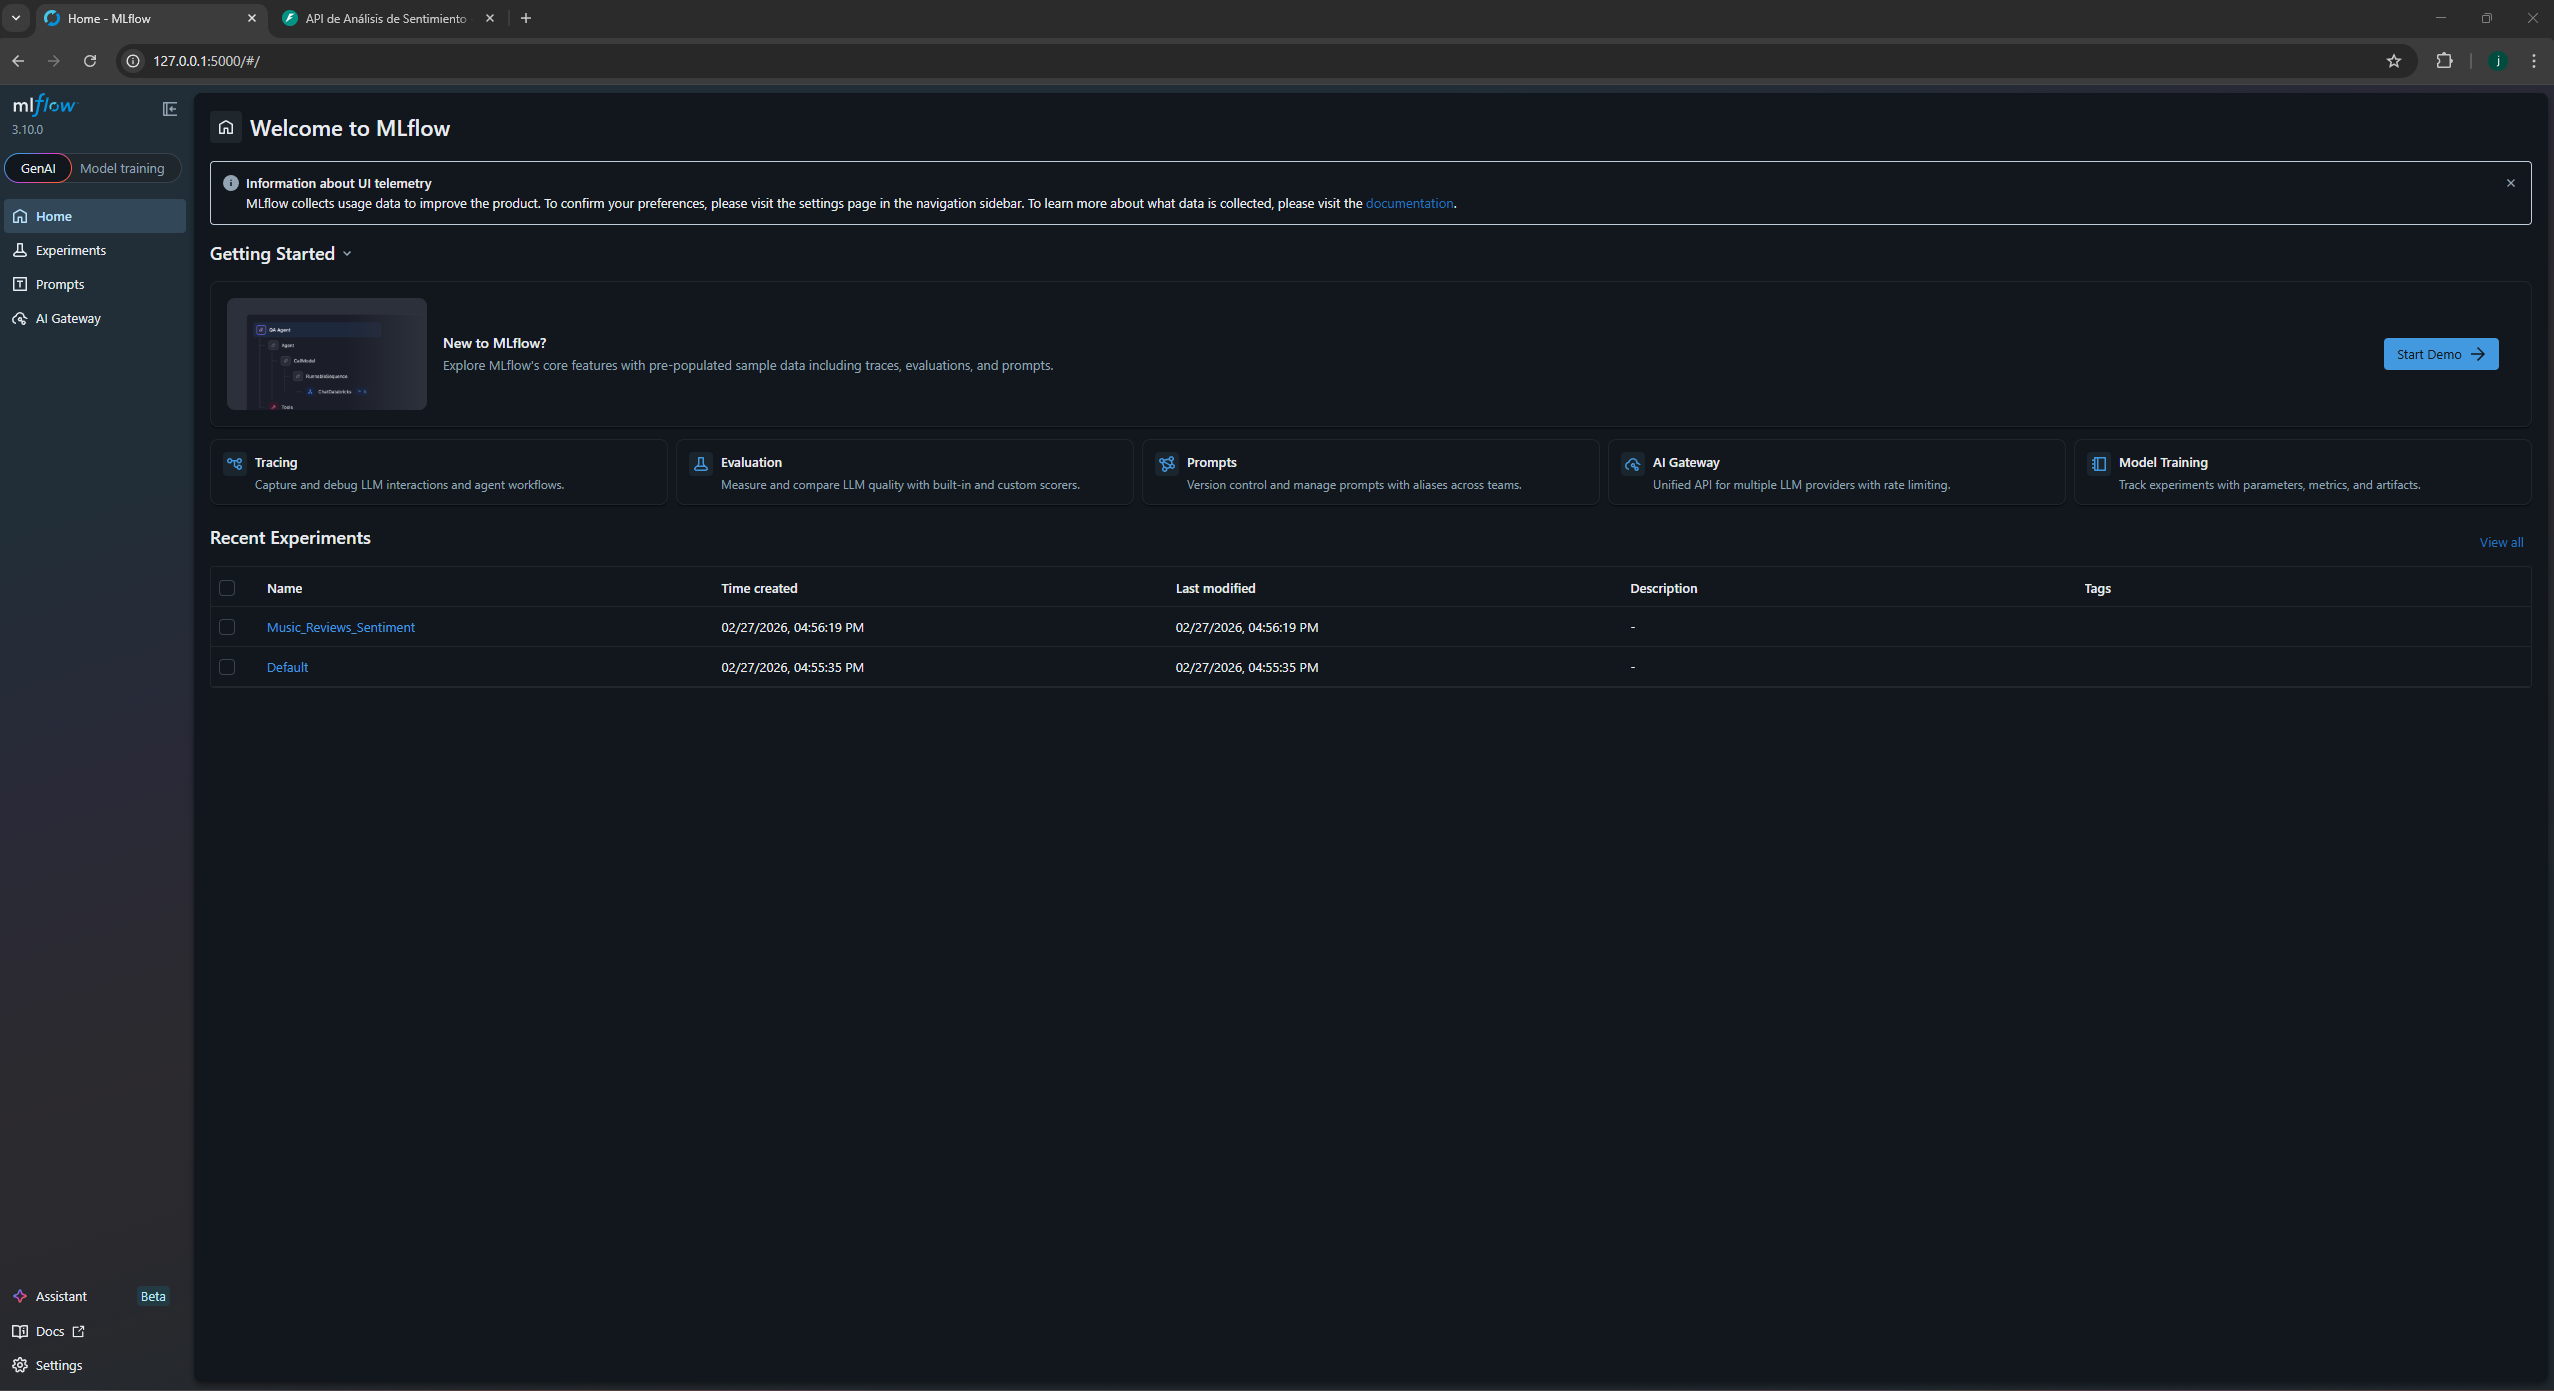

In [7]:
# Captura de la interfaz de MLflow
from IPython.display import Image, display
display(Image('Vista_Mlflow.png'))

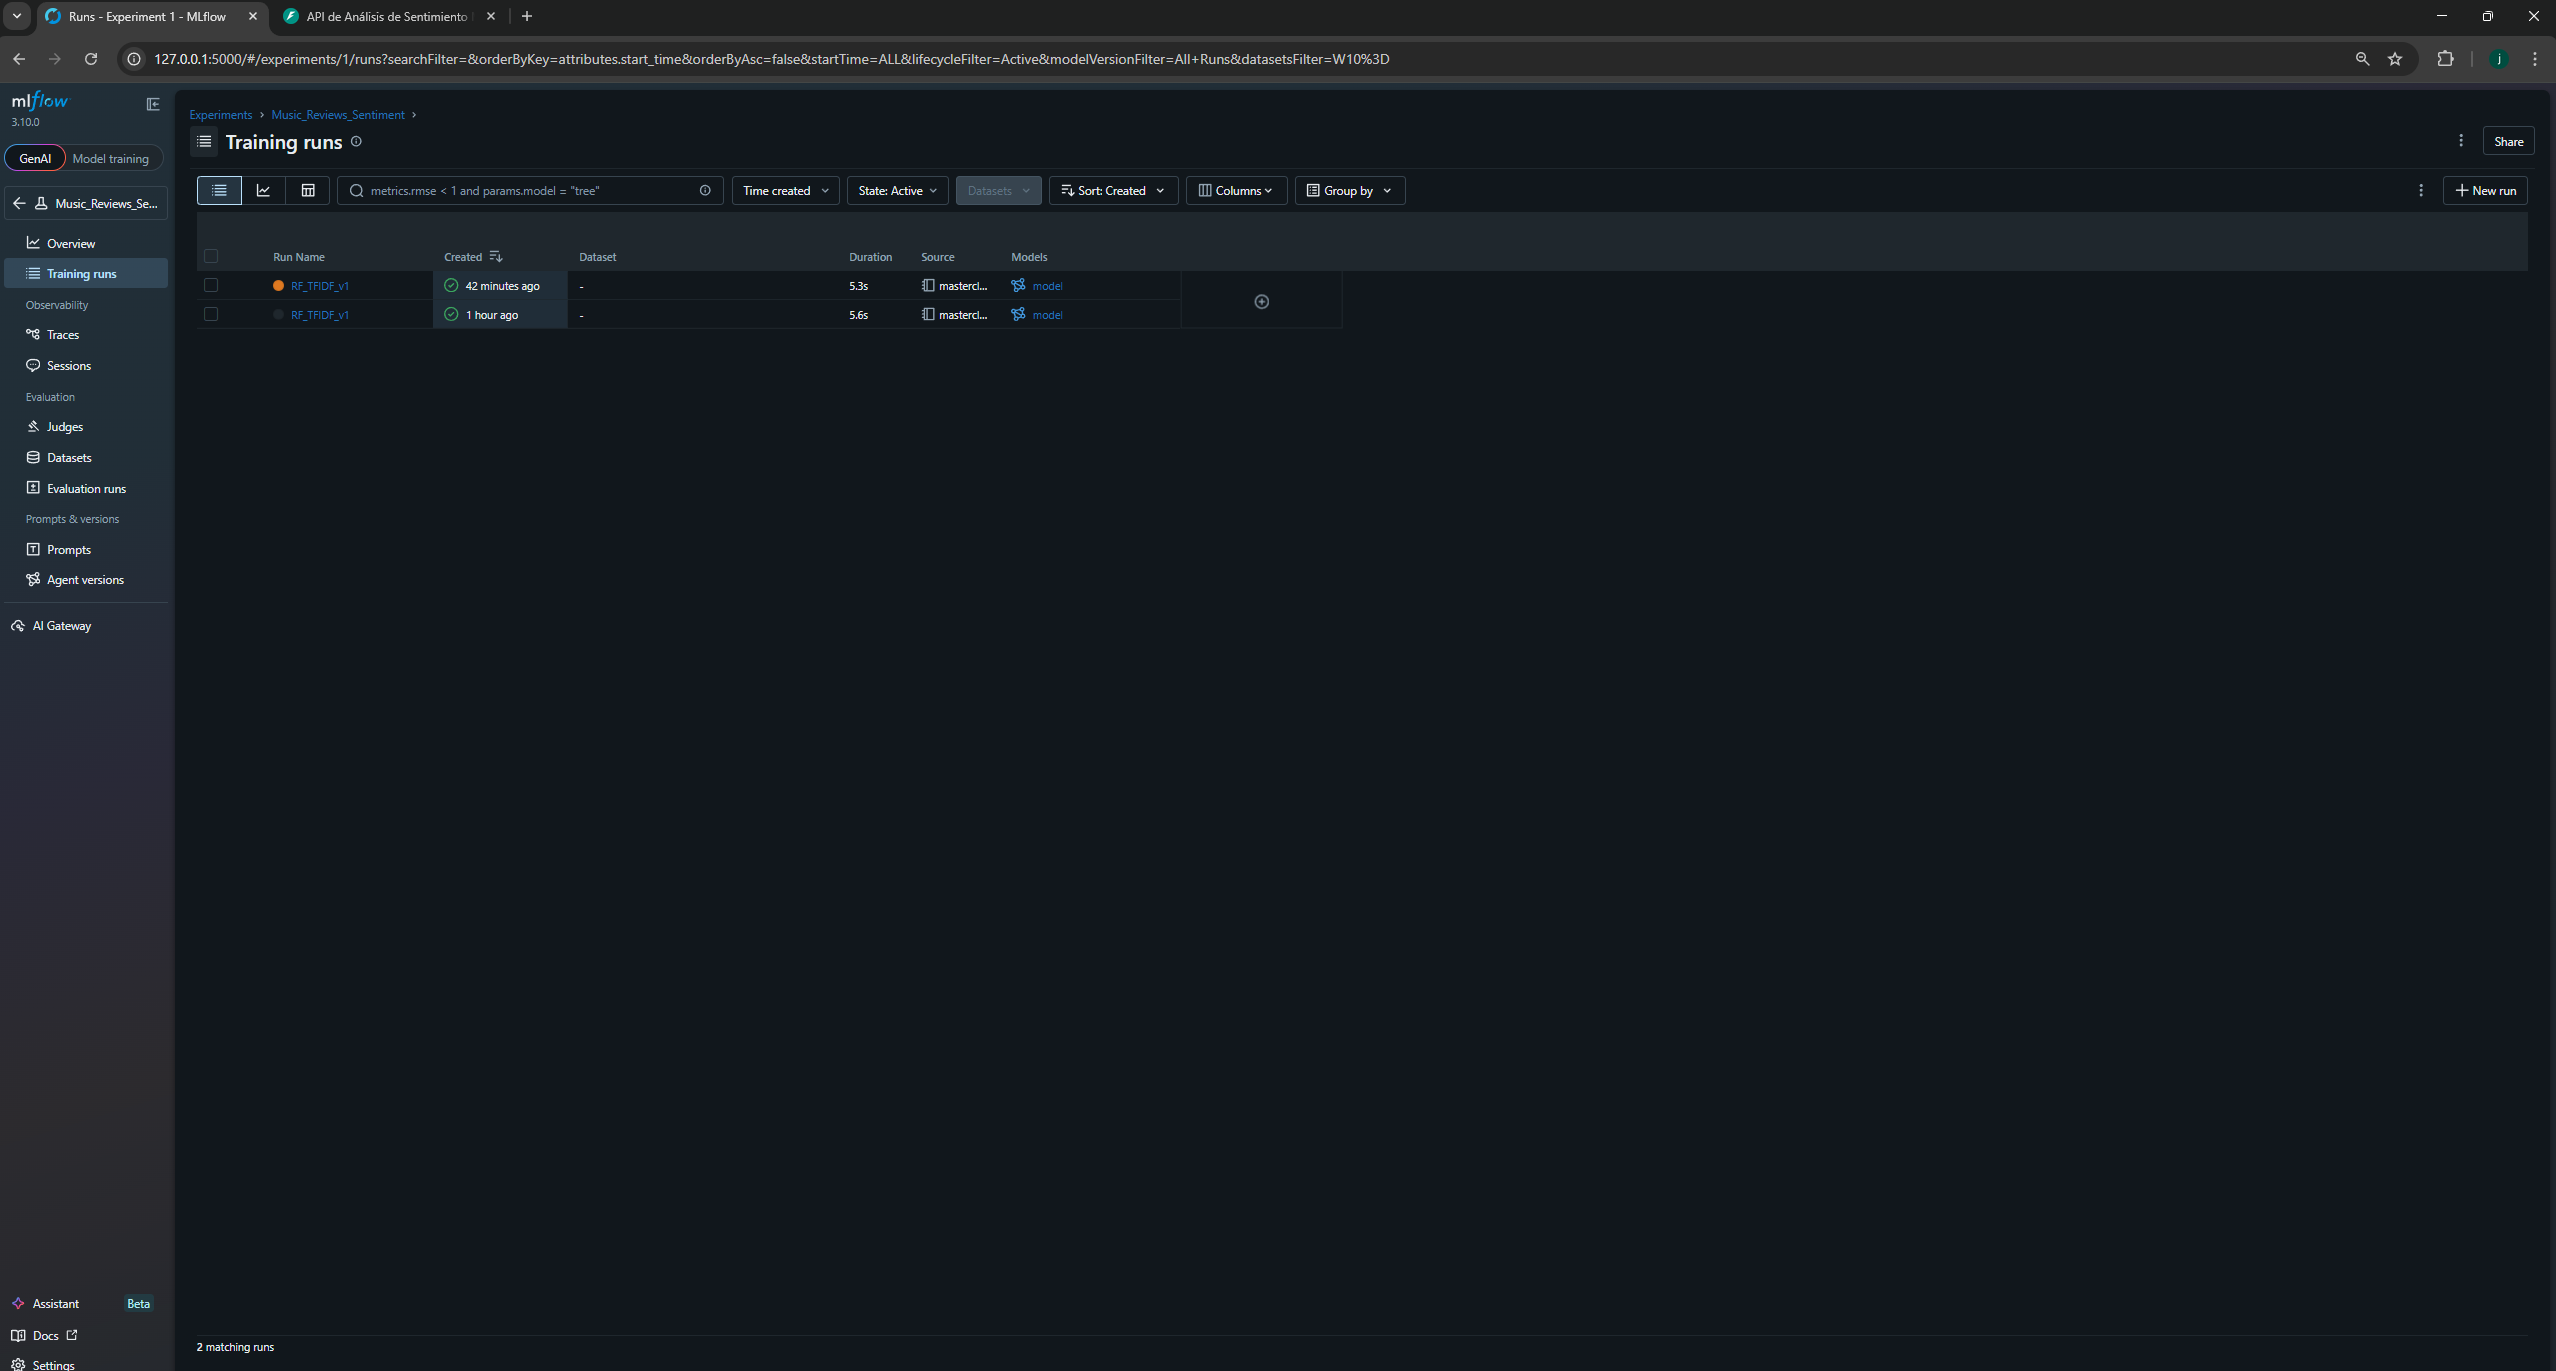

In [15]:
display(Image('Vista_Mlflow1.png'))

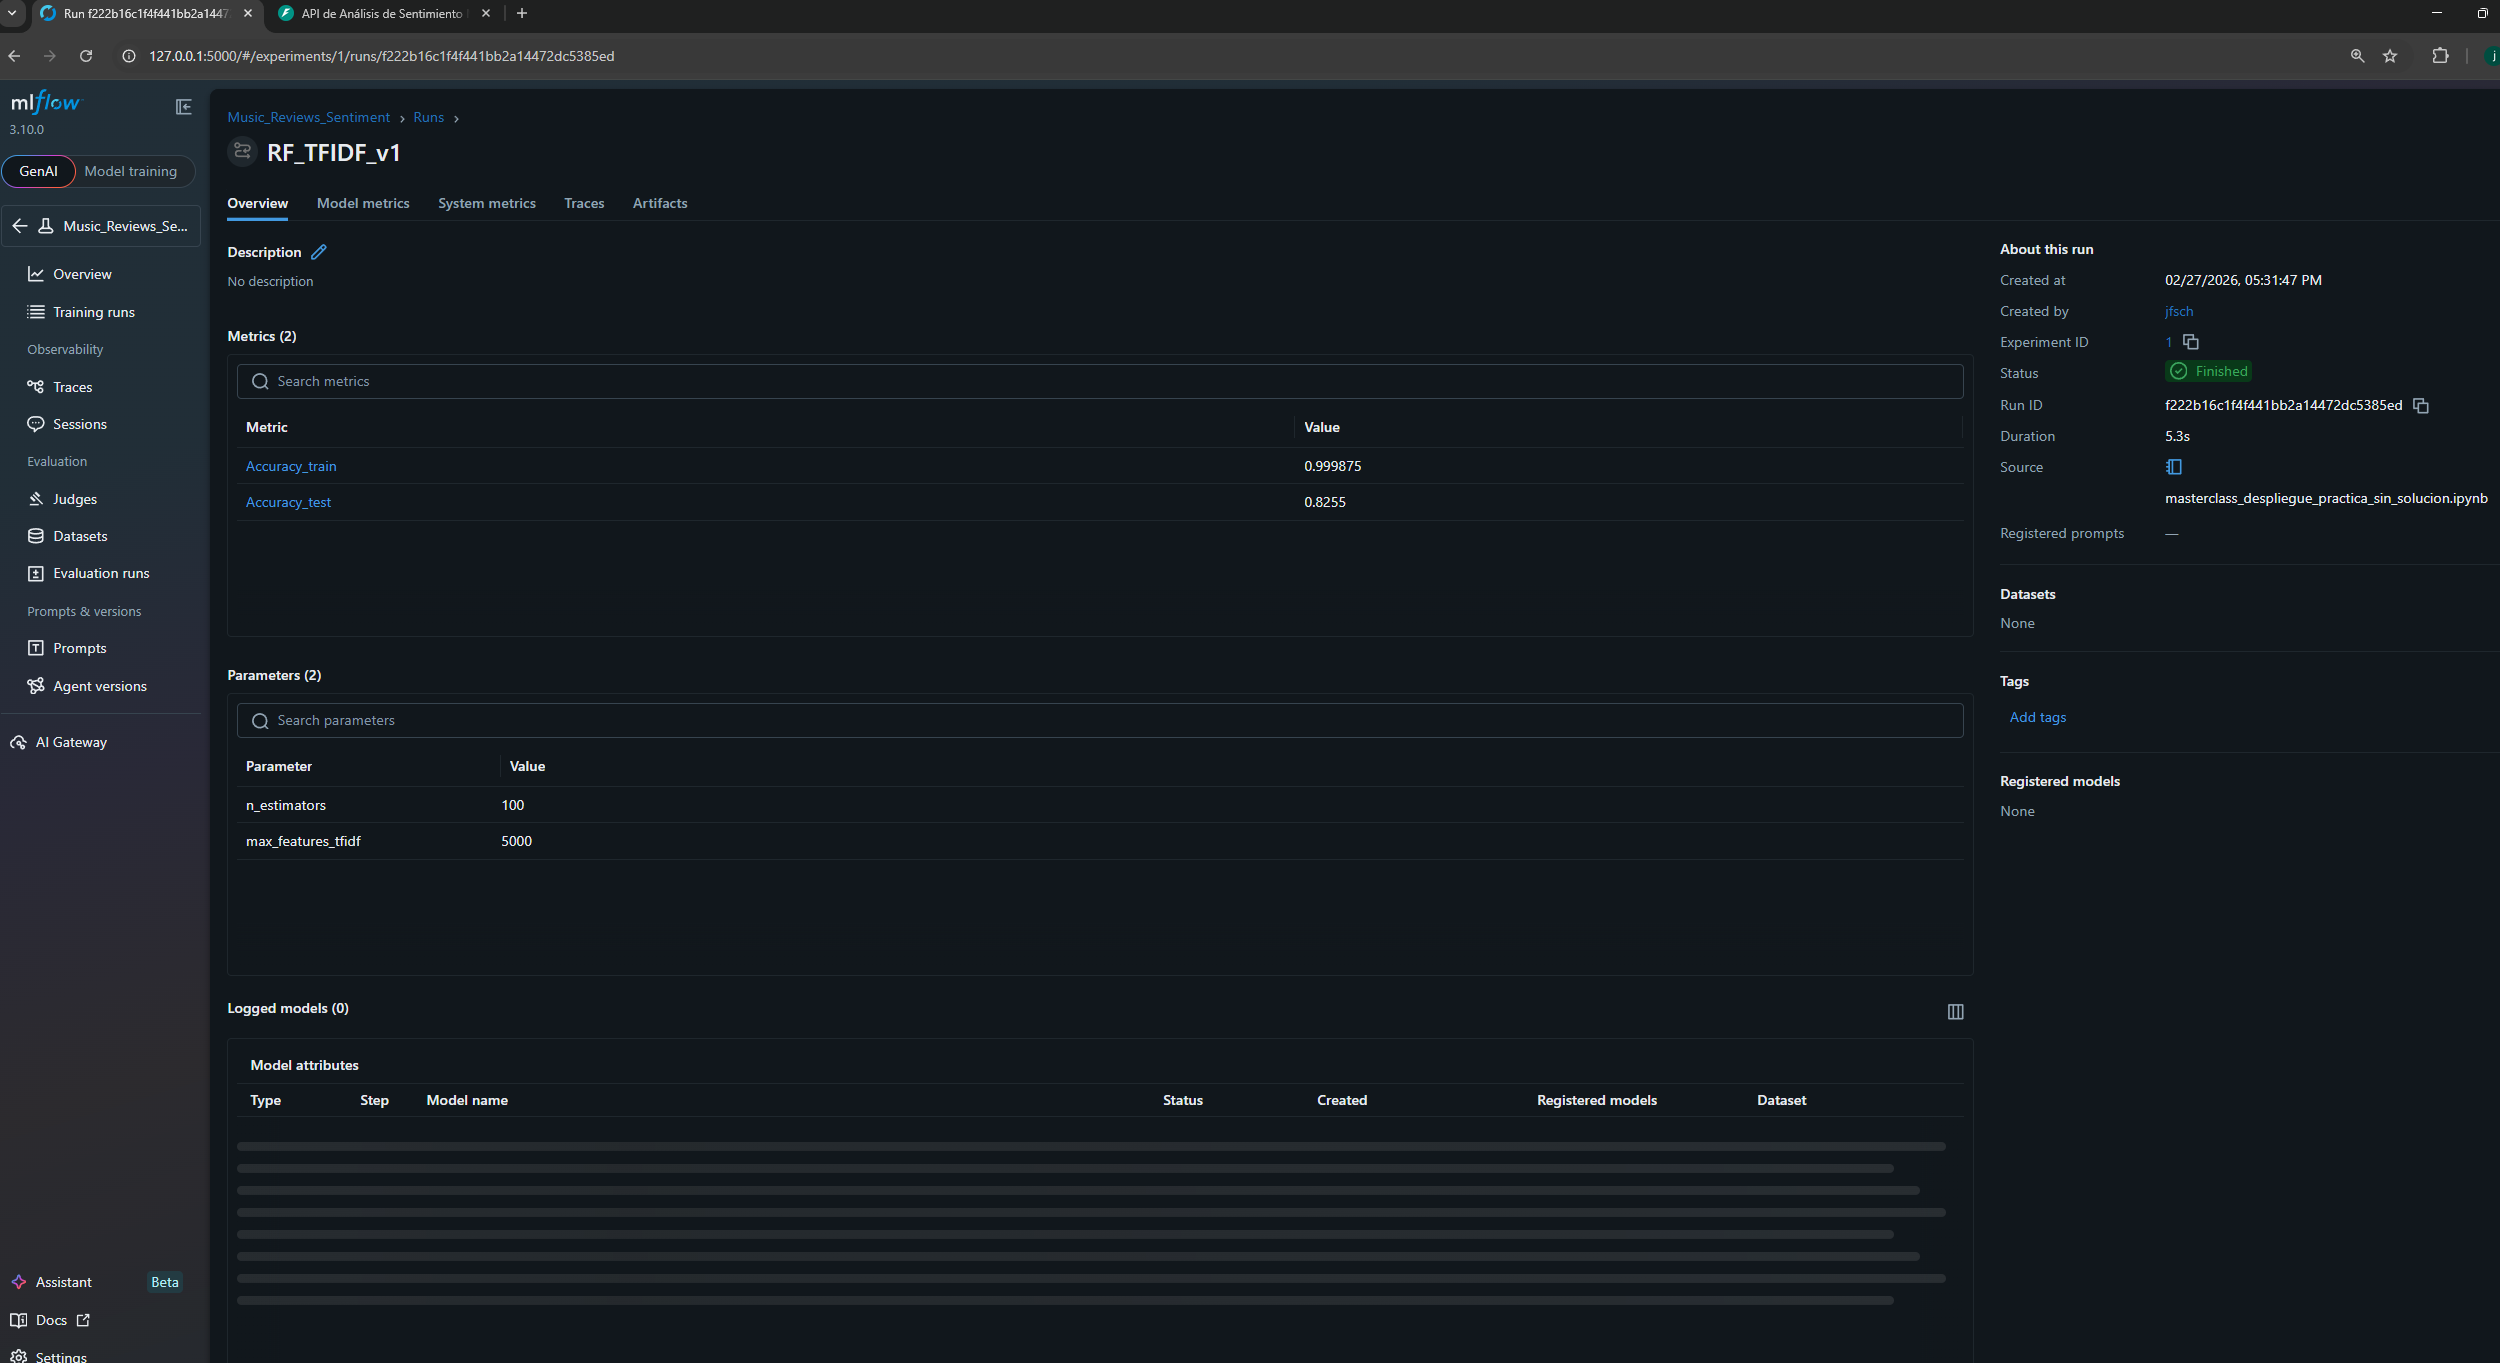

In [14]:
display(Image('Vista_Mlflow2.png'))

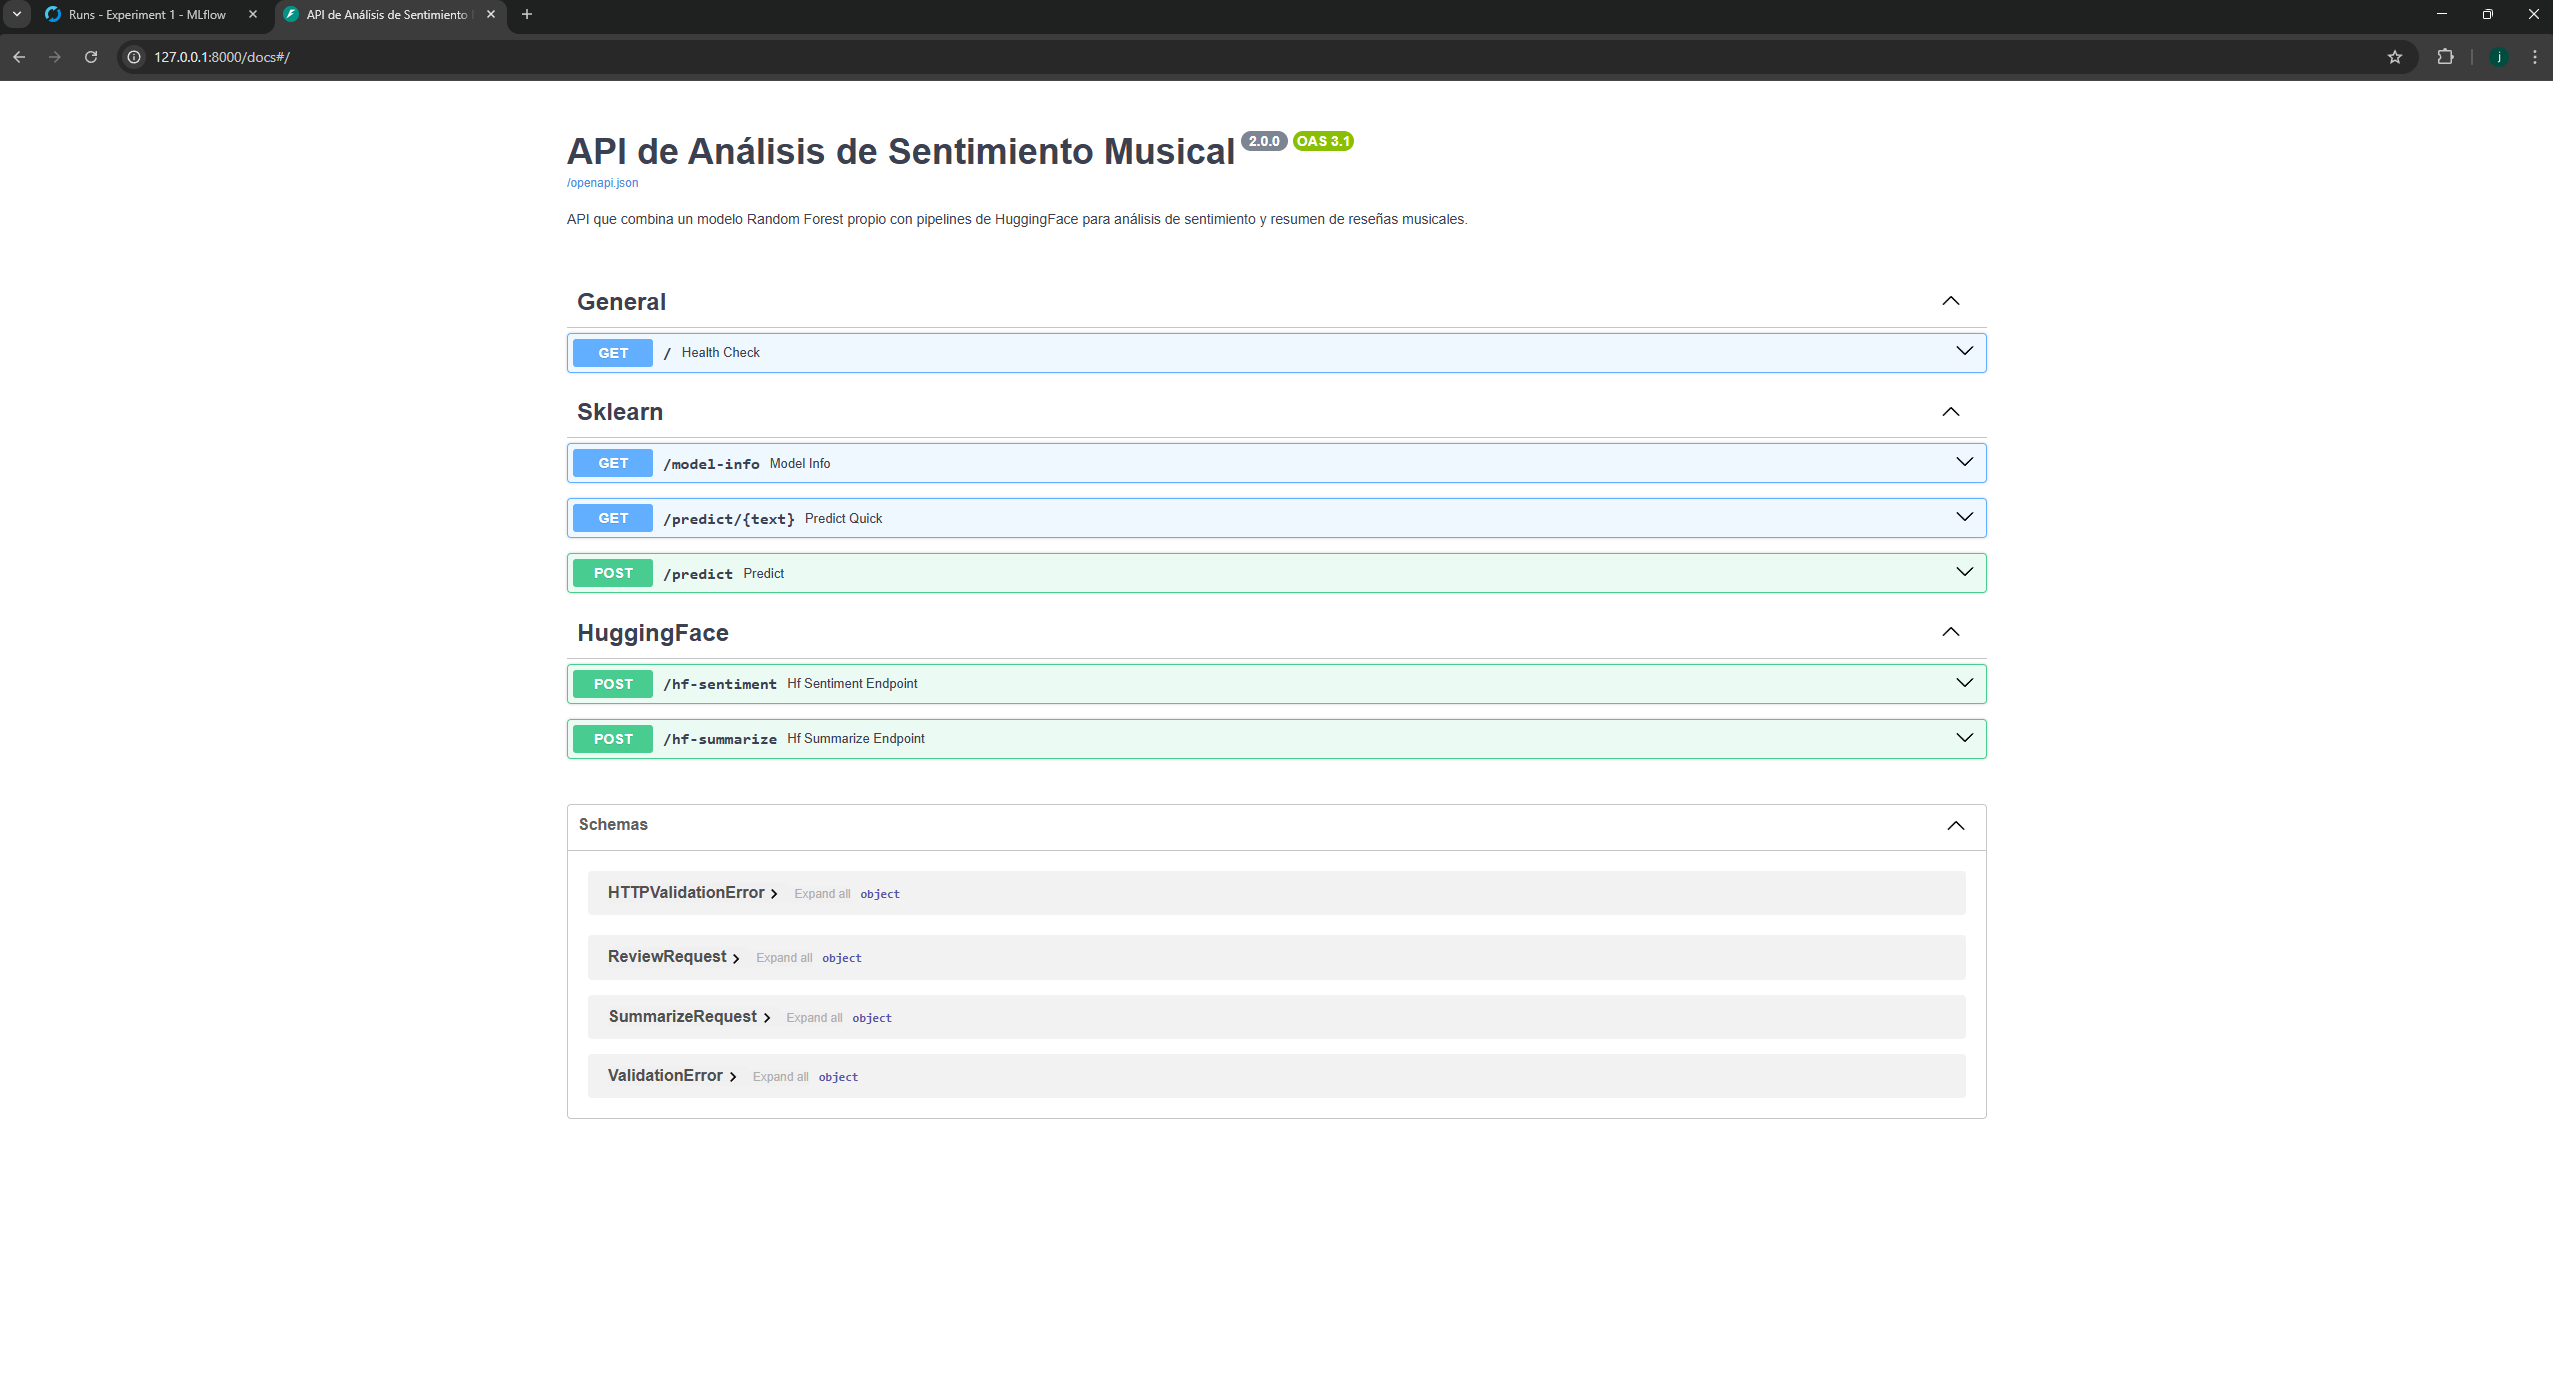

In [12]:
# Captura de la interfaz de Fast API
display(Image('Vista_Fast_API.png'))

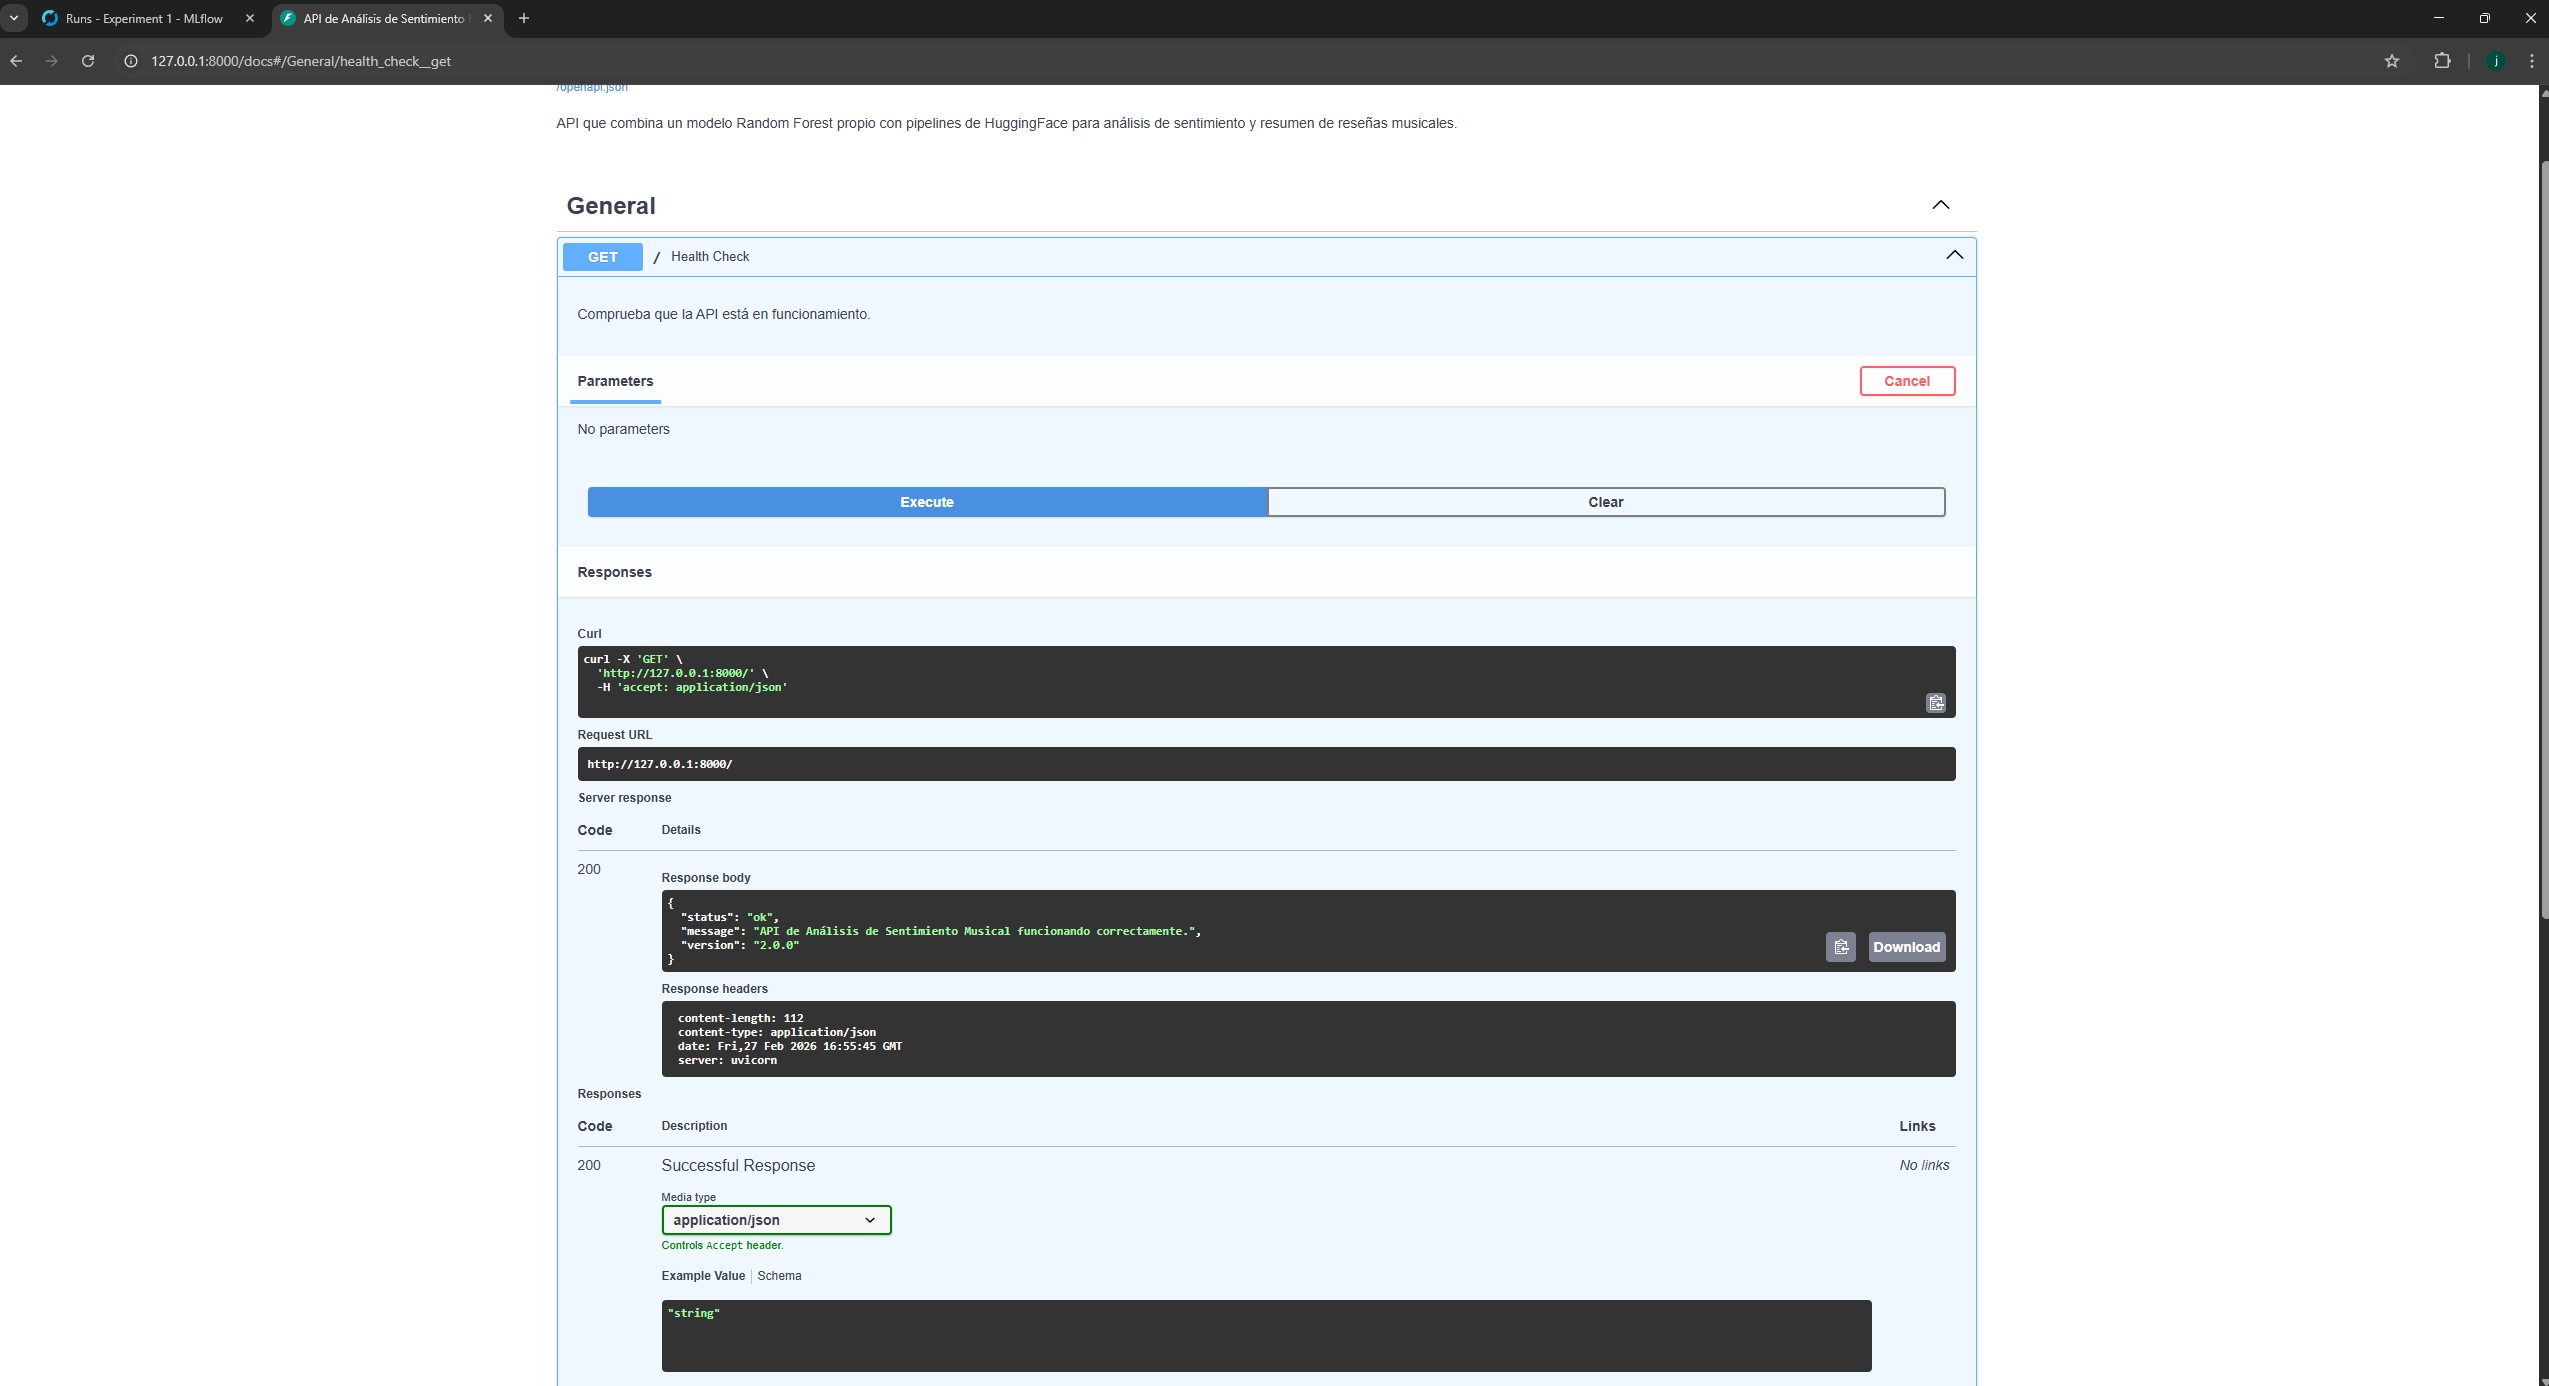

In [16]:
display(Image('Vista_General.png'))

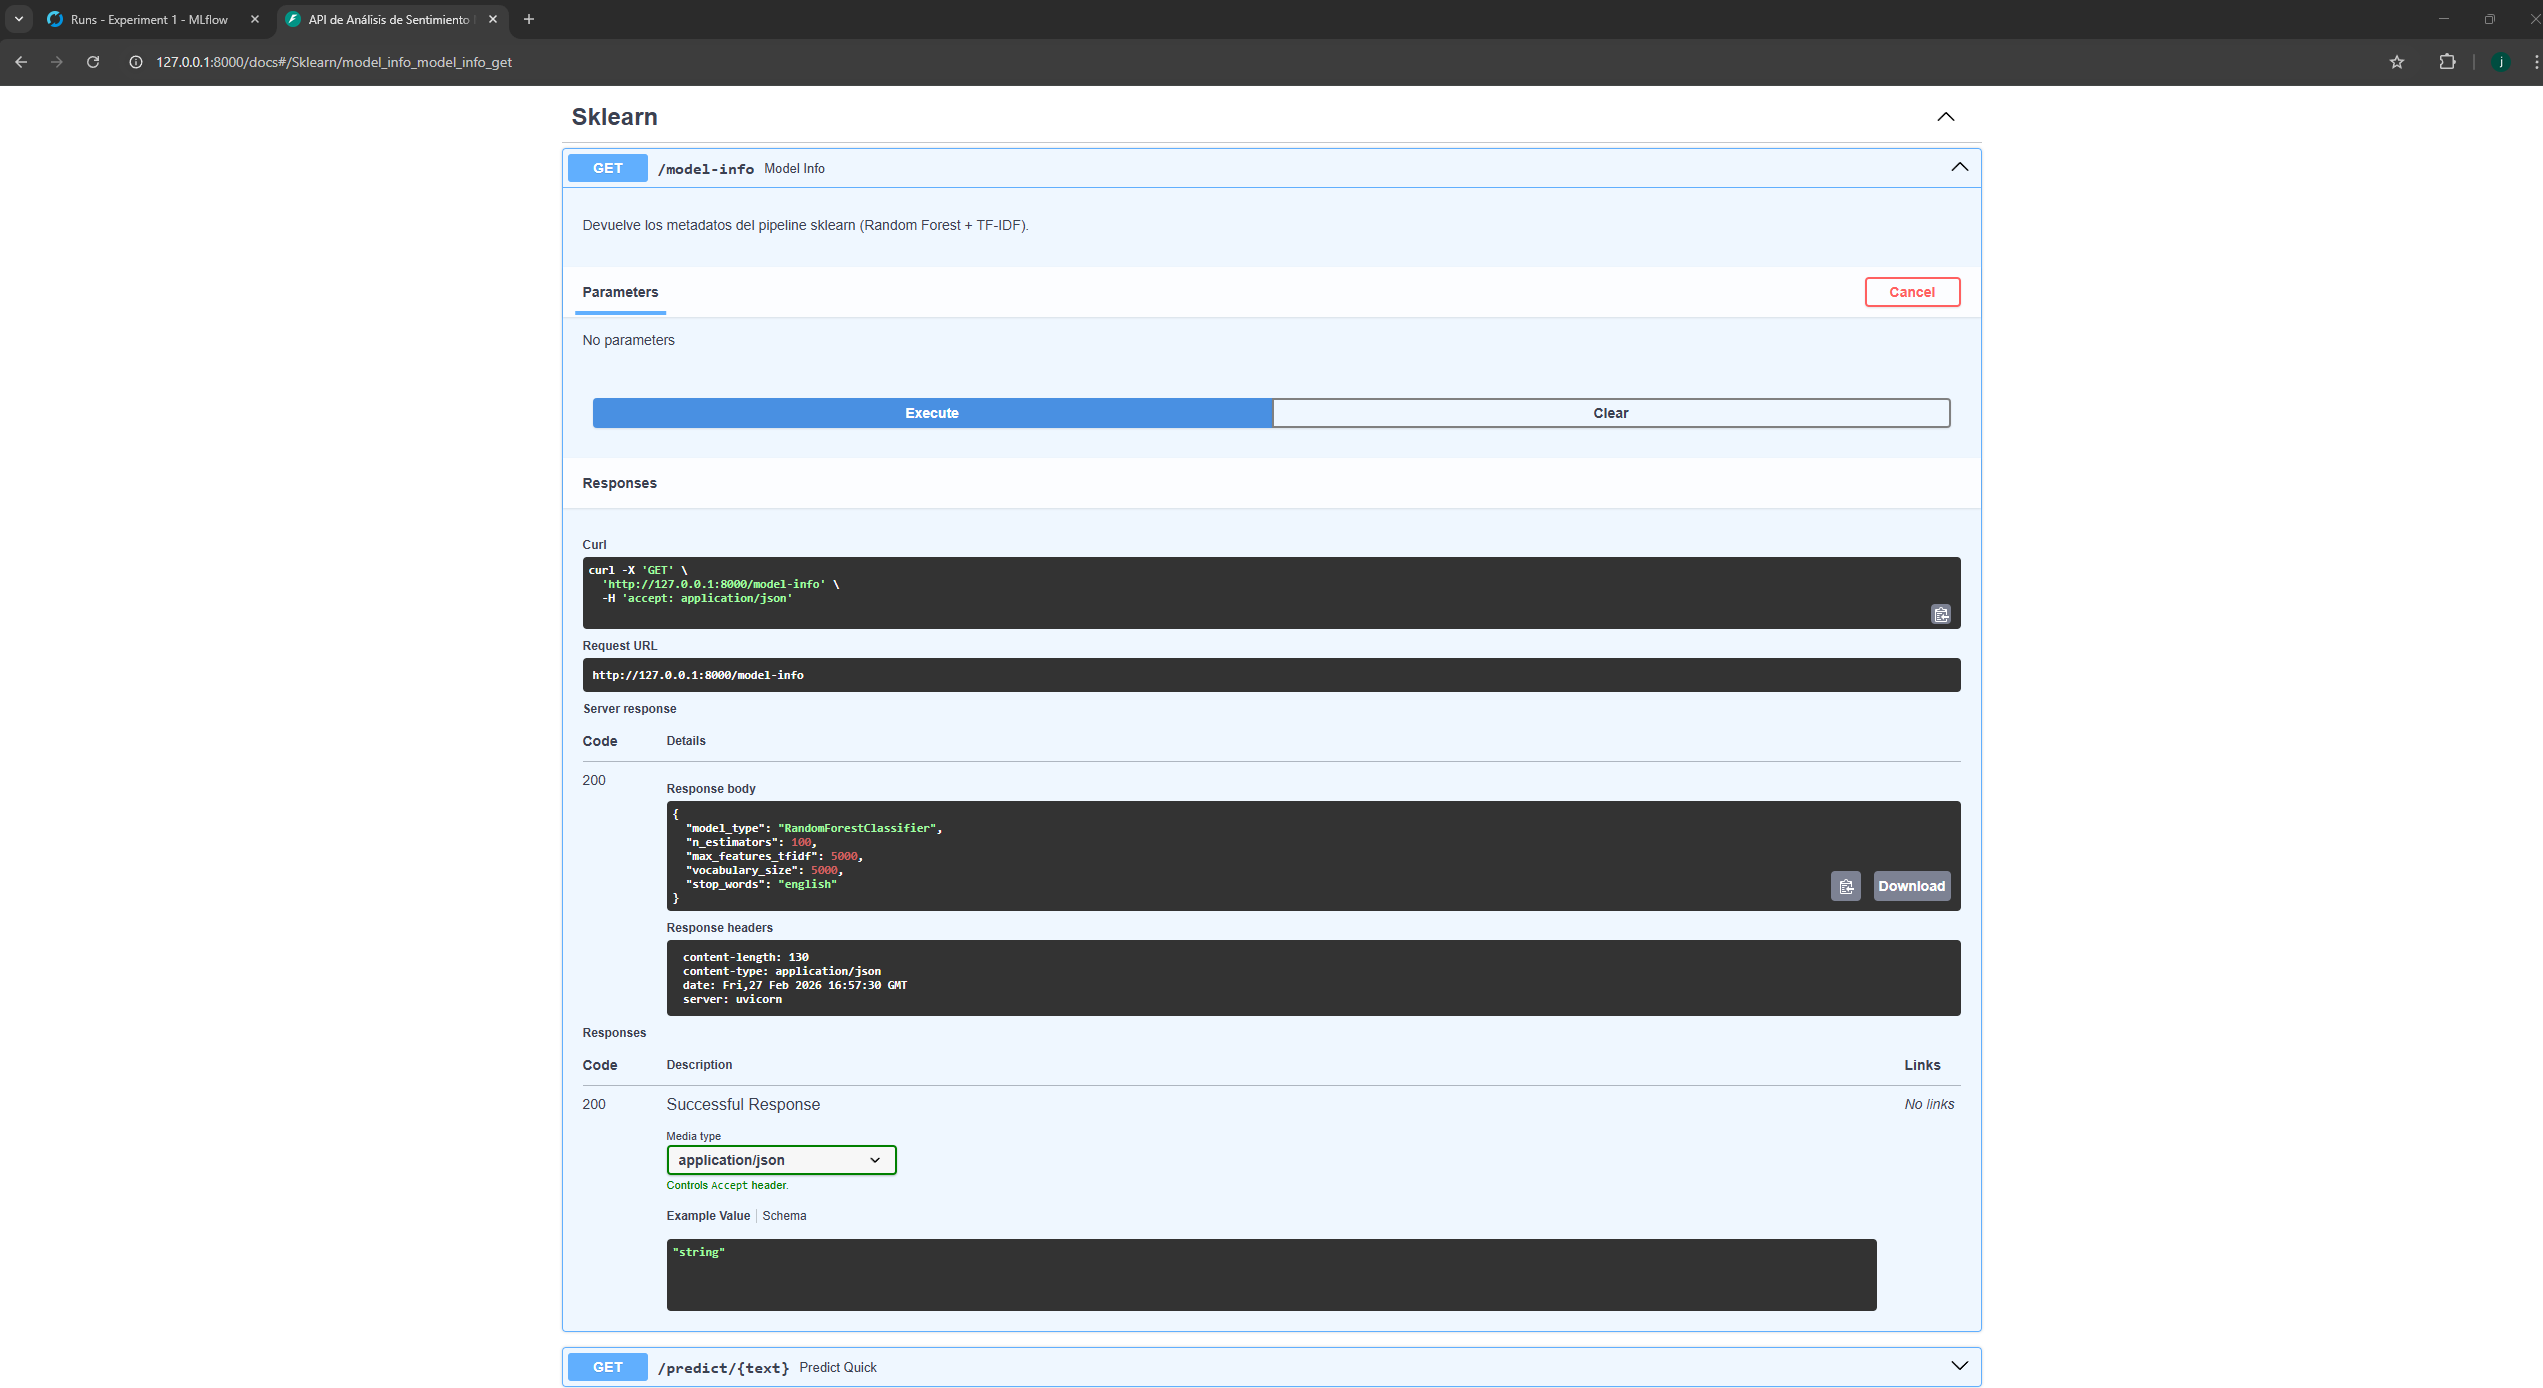

In [17]:
display(Image('Vista_Sklearn.png'))

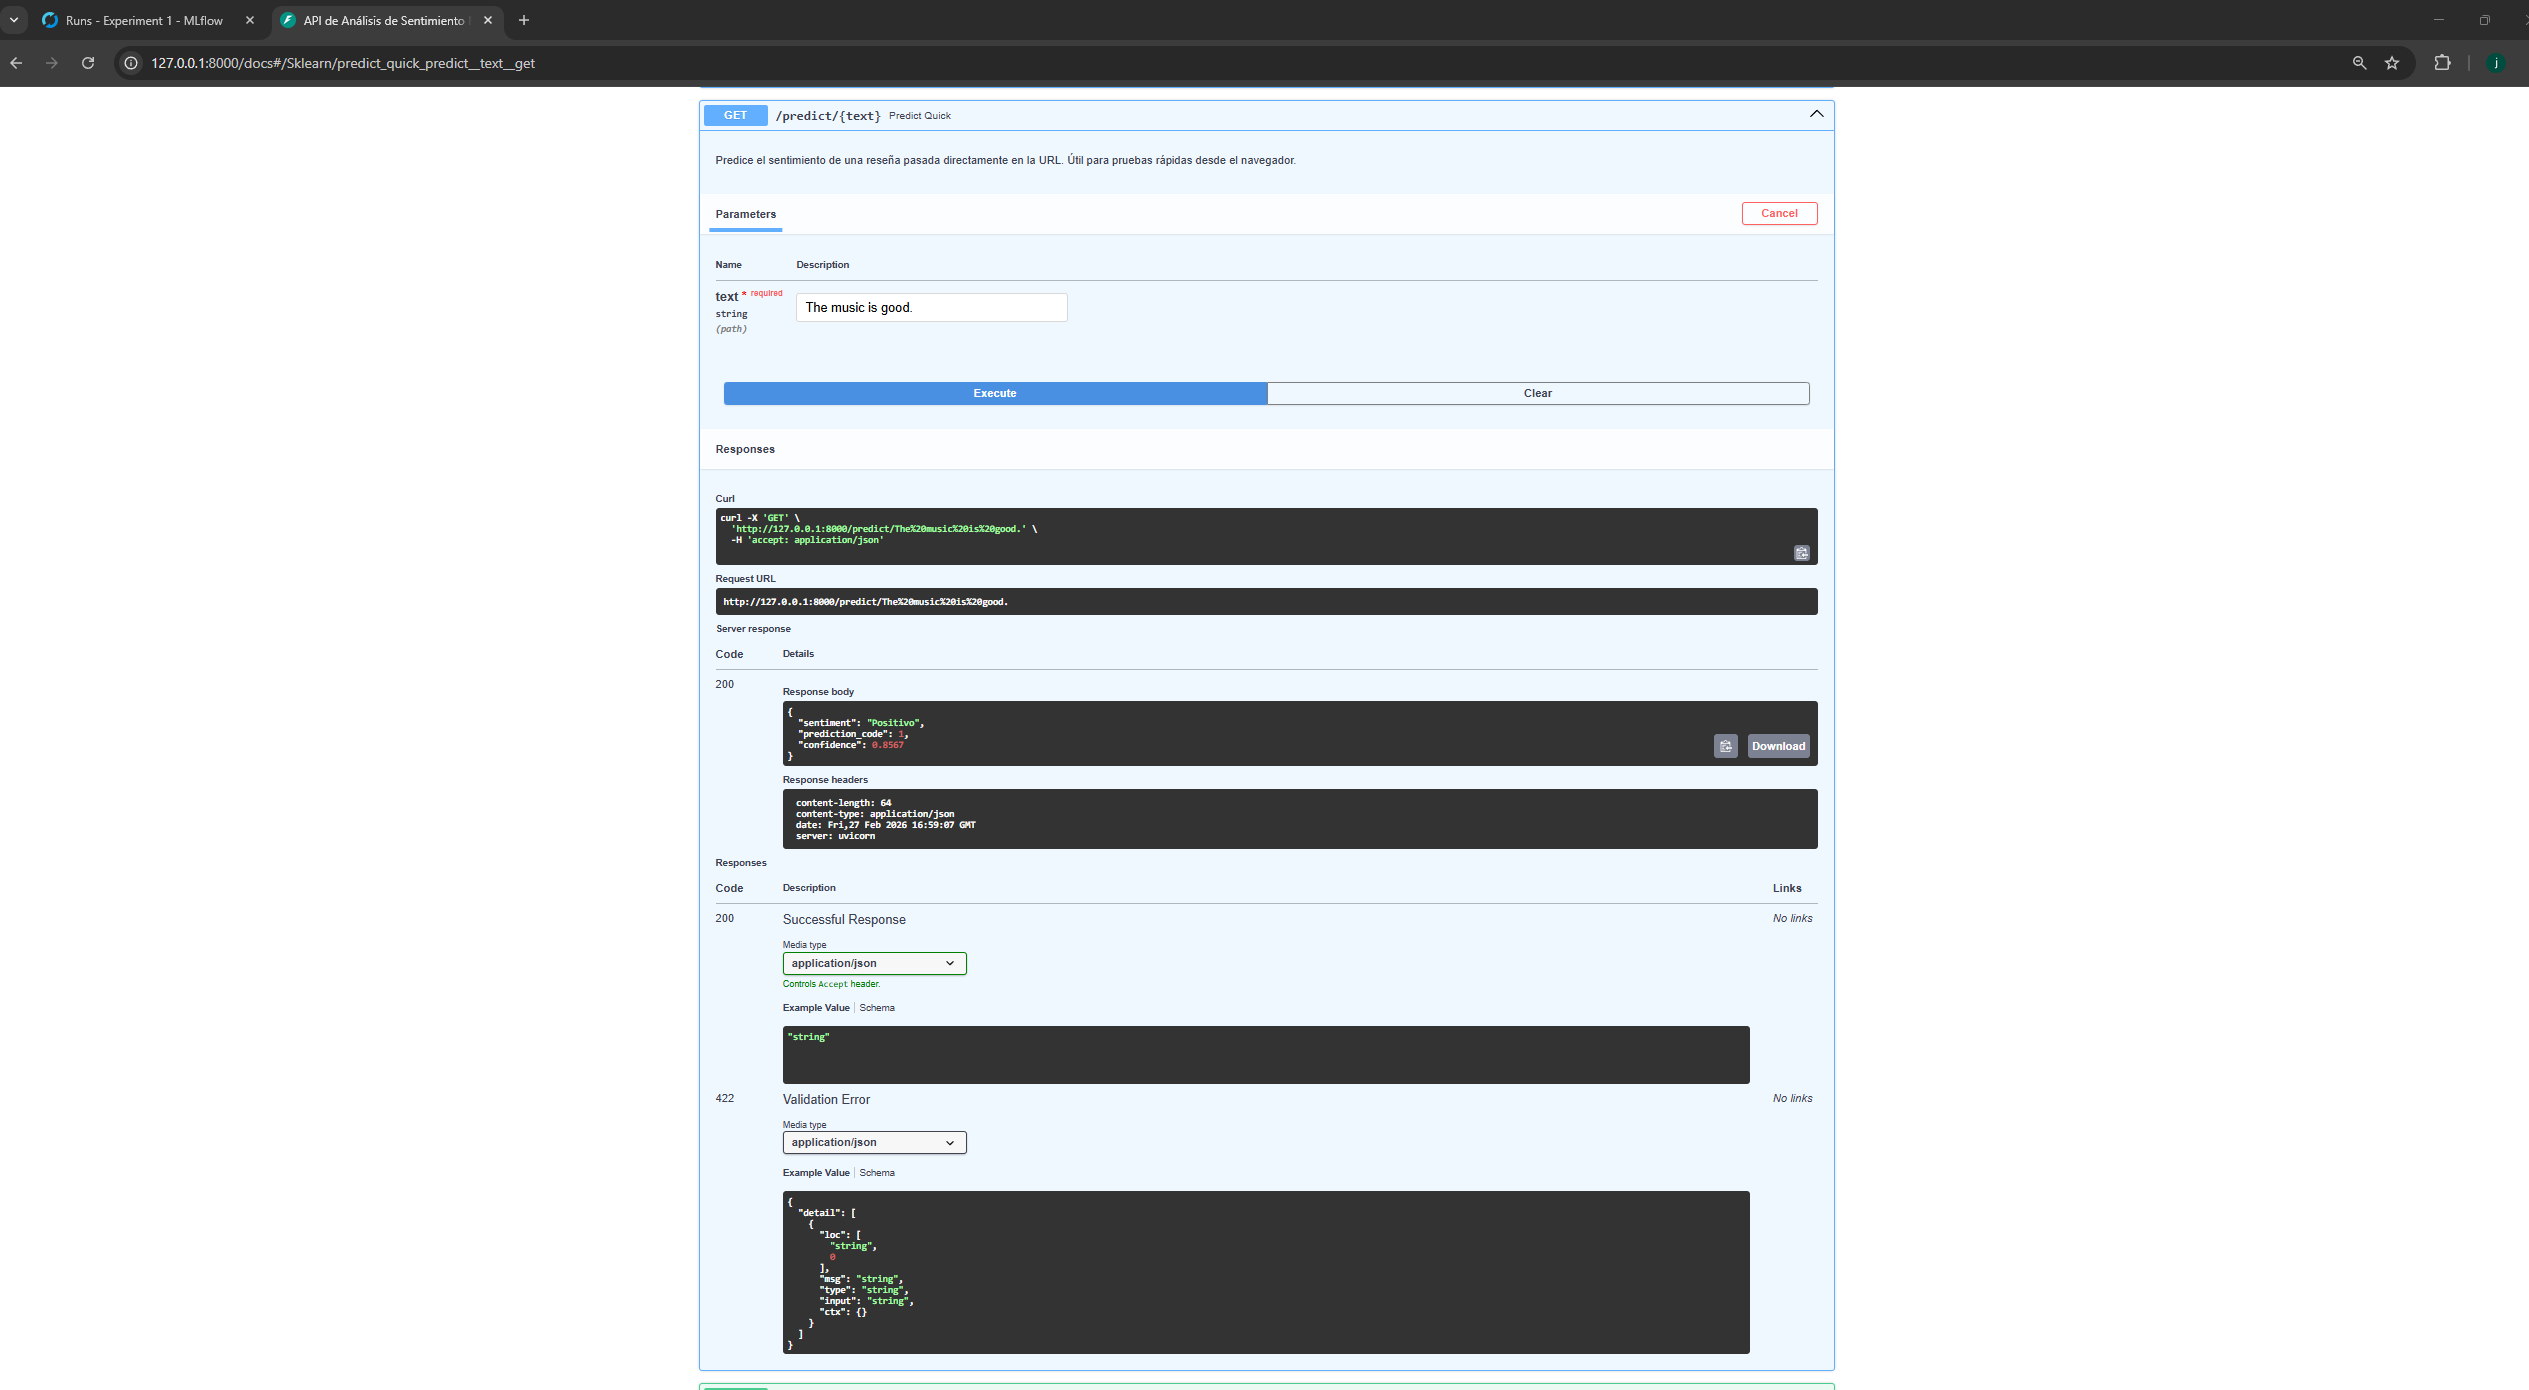

In [18]:
display(Image('Vista_Sklearn2.png'))

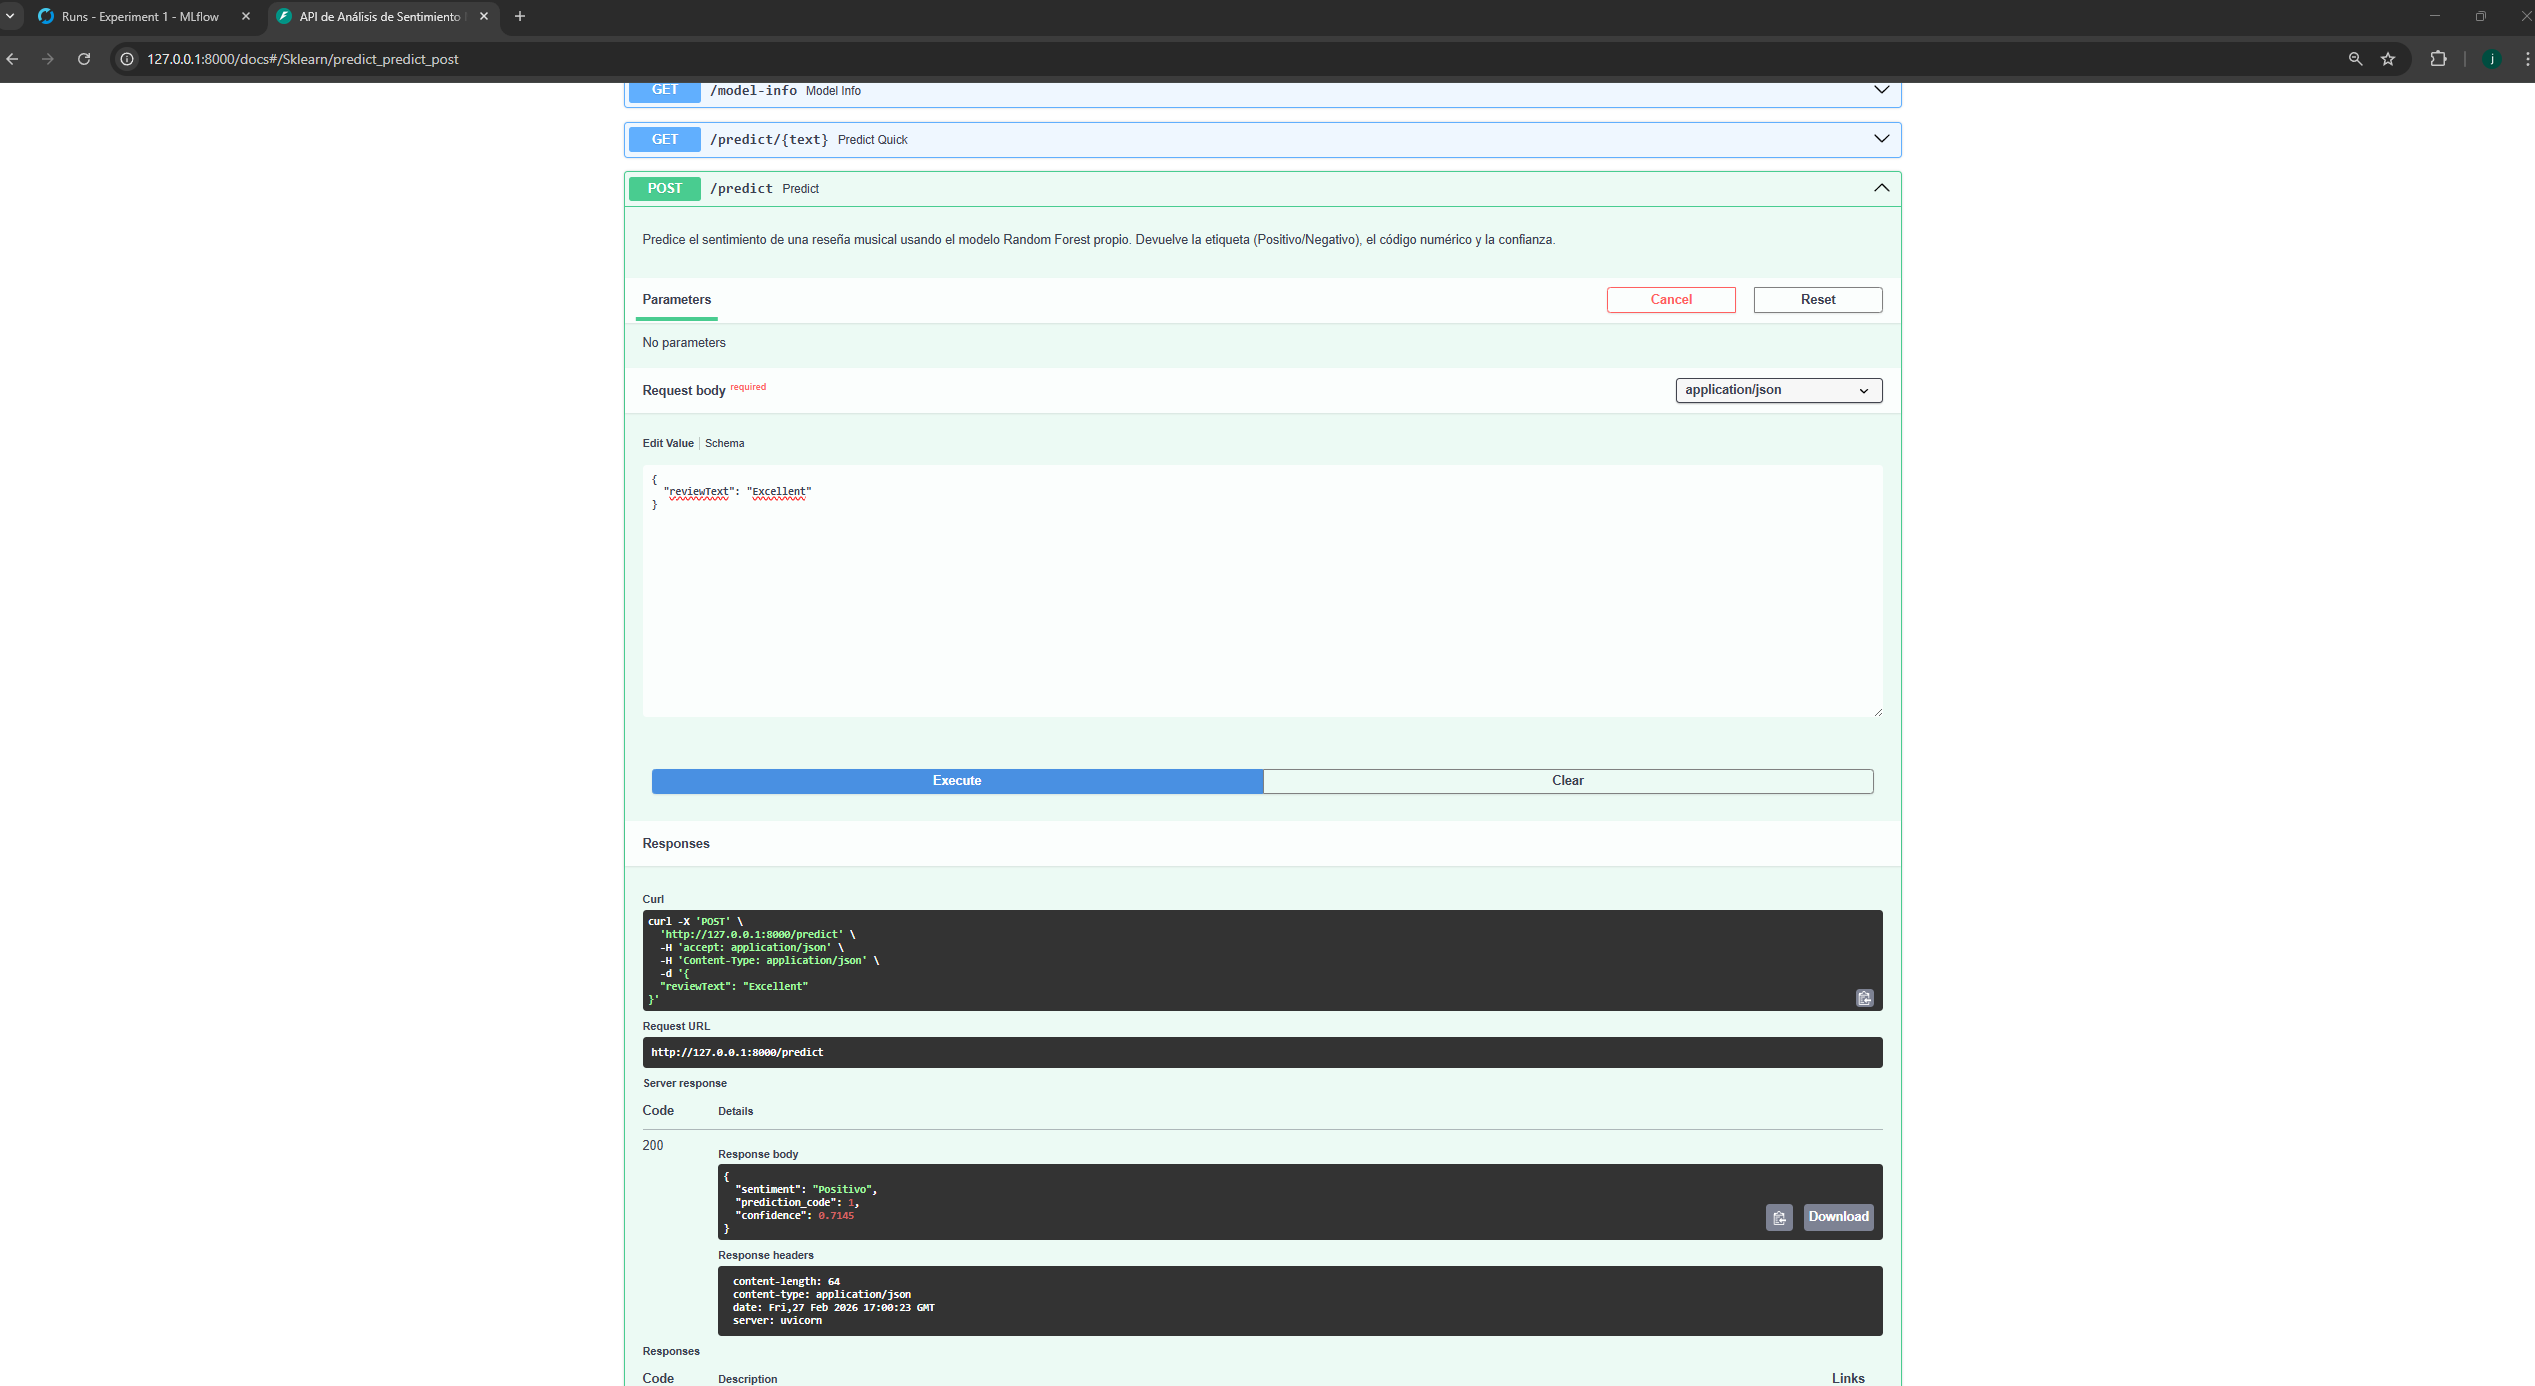

In [19]:
display(Image('Vista_Sklearn3.png'))

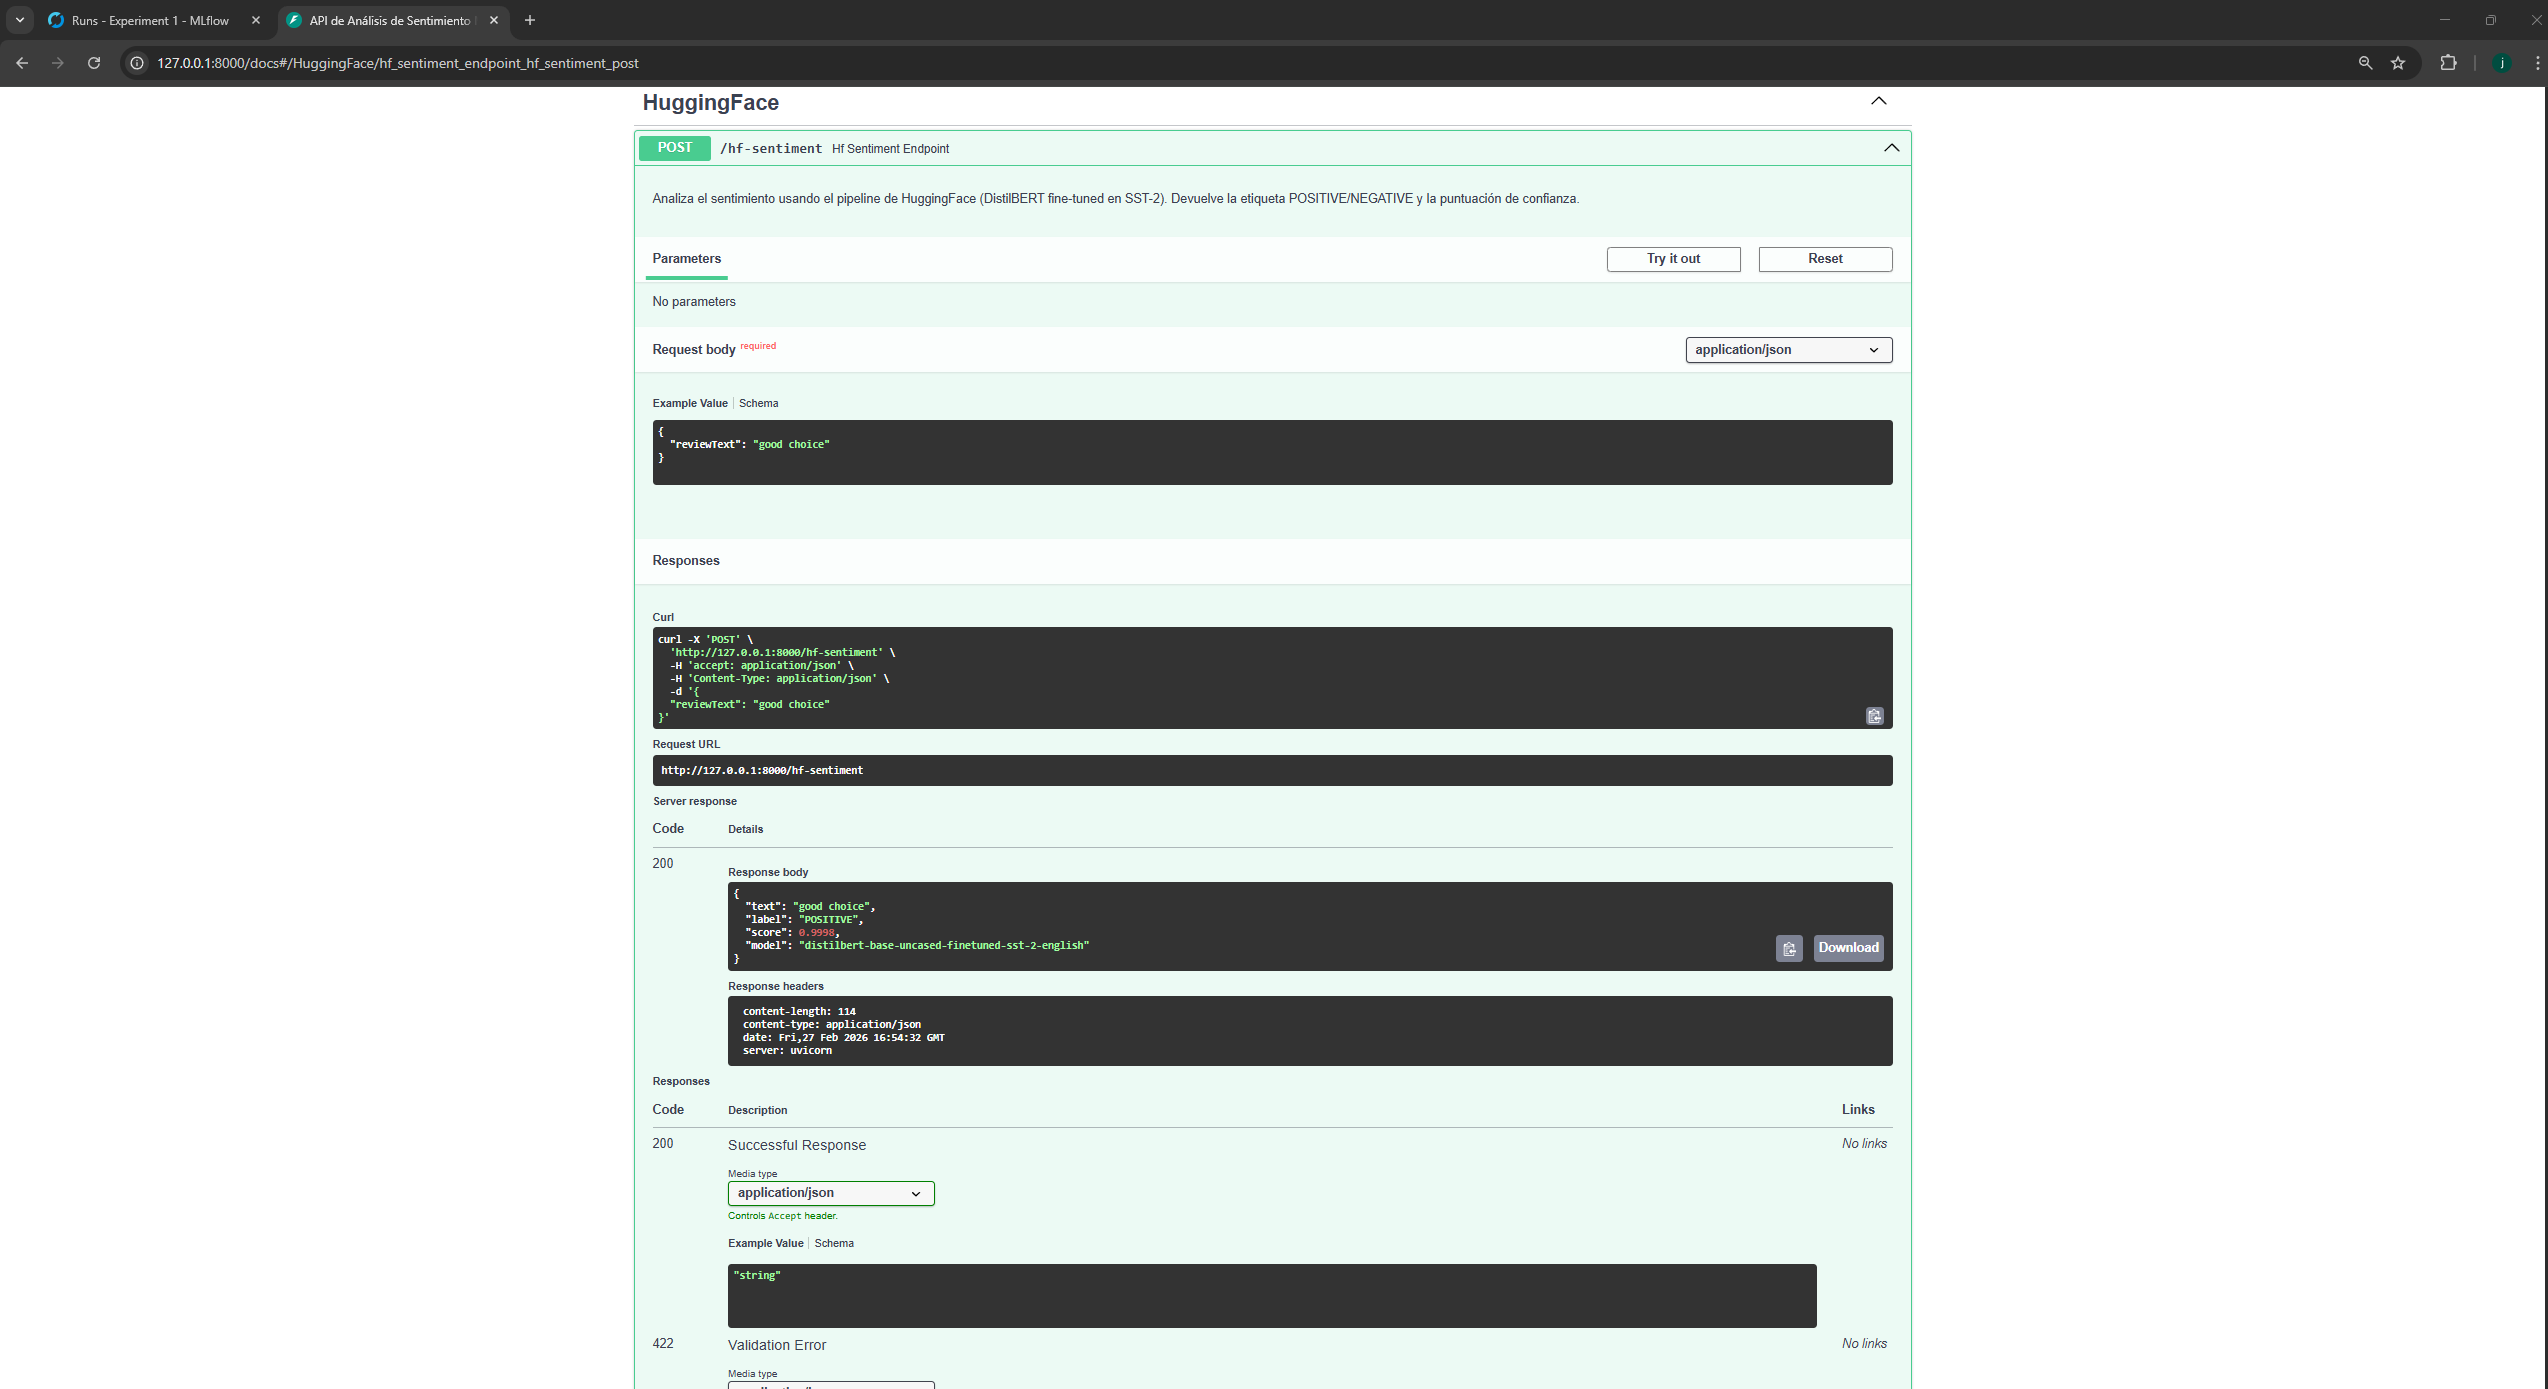

In [20]:
display(Image('Huggin_1.png'))

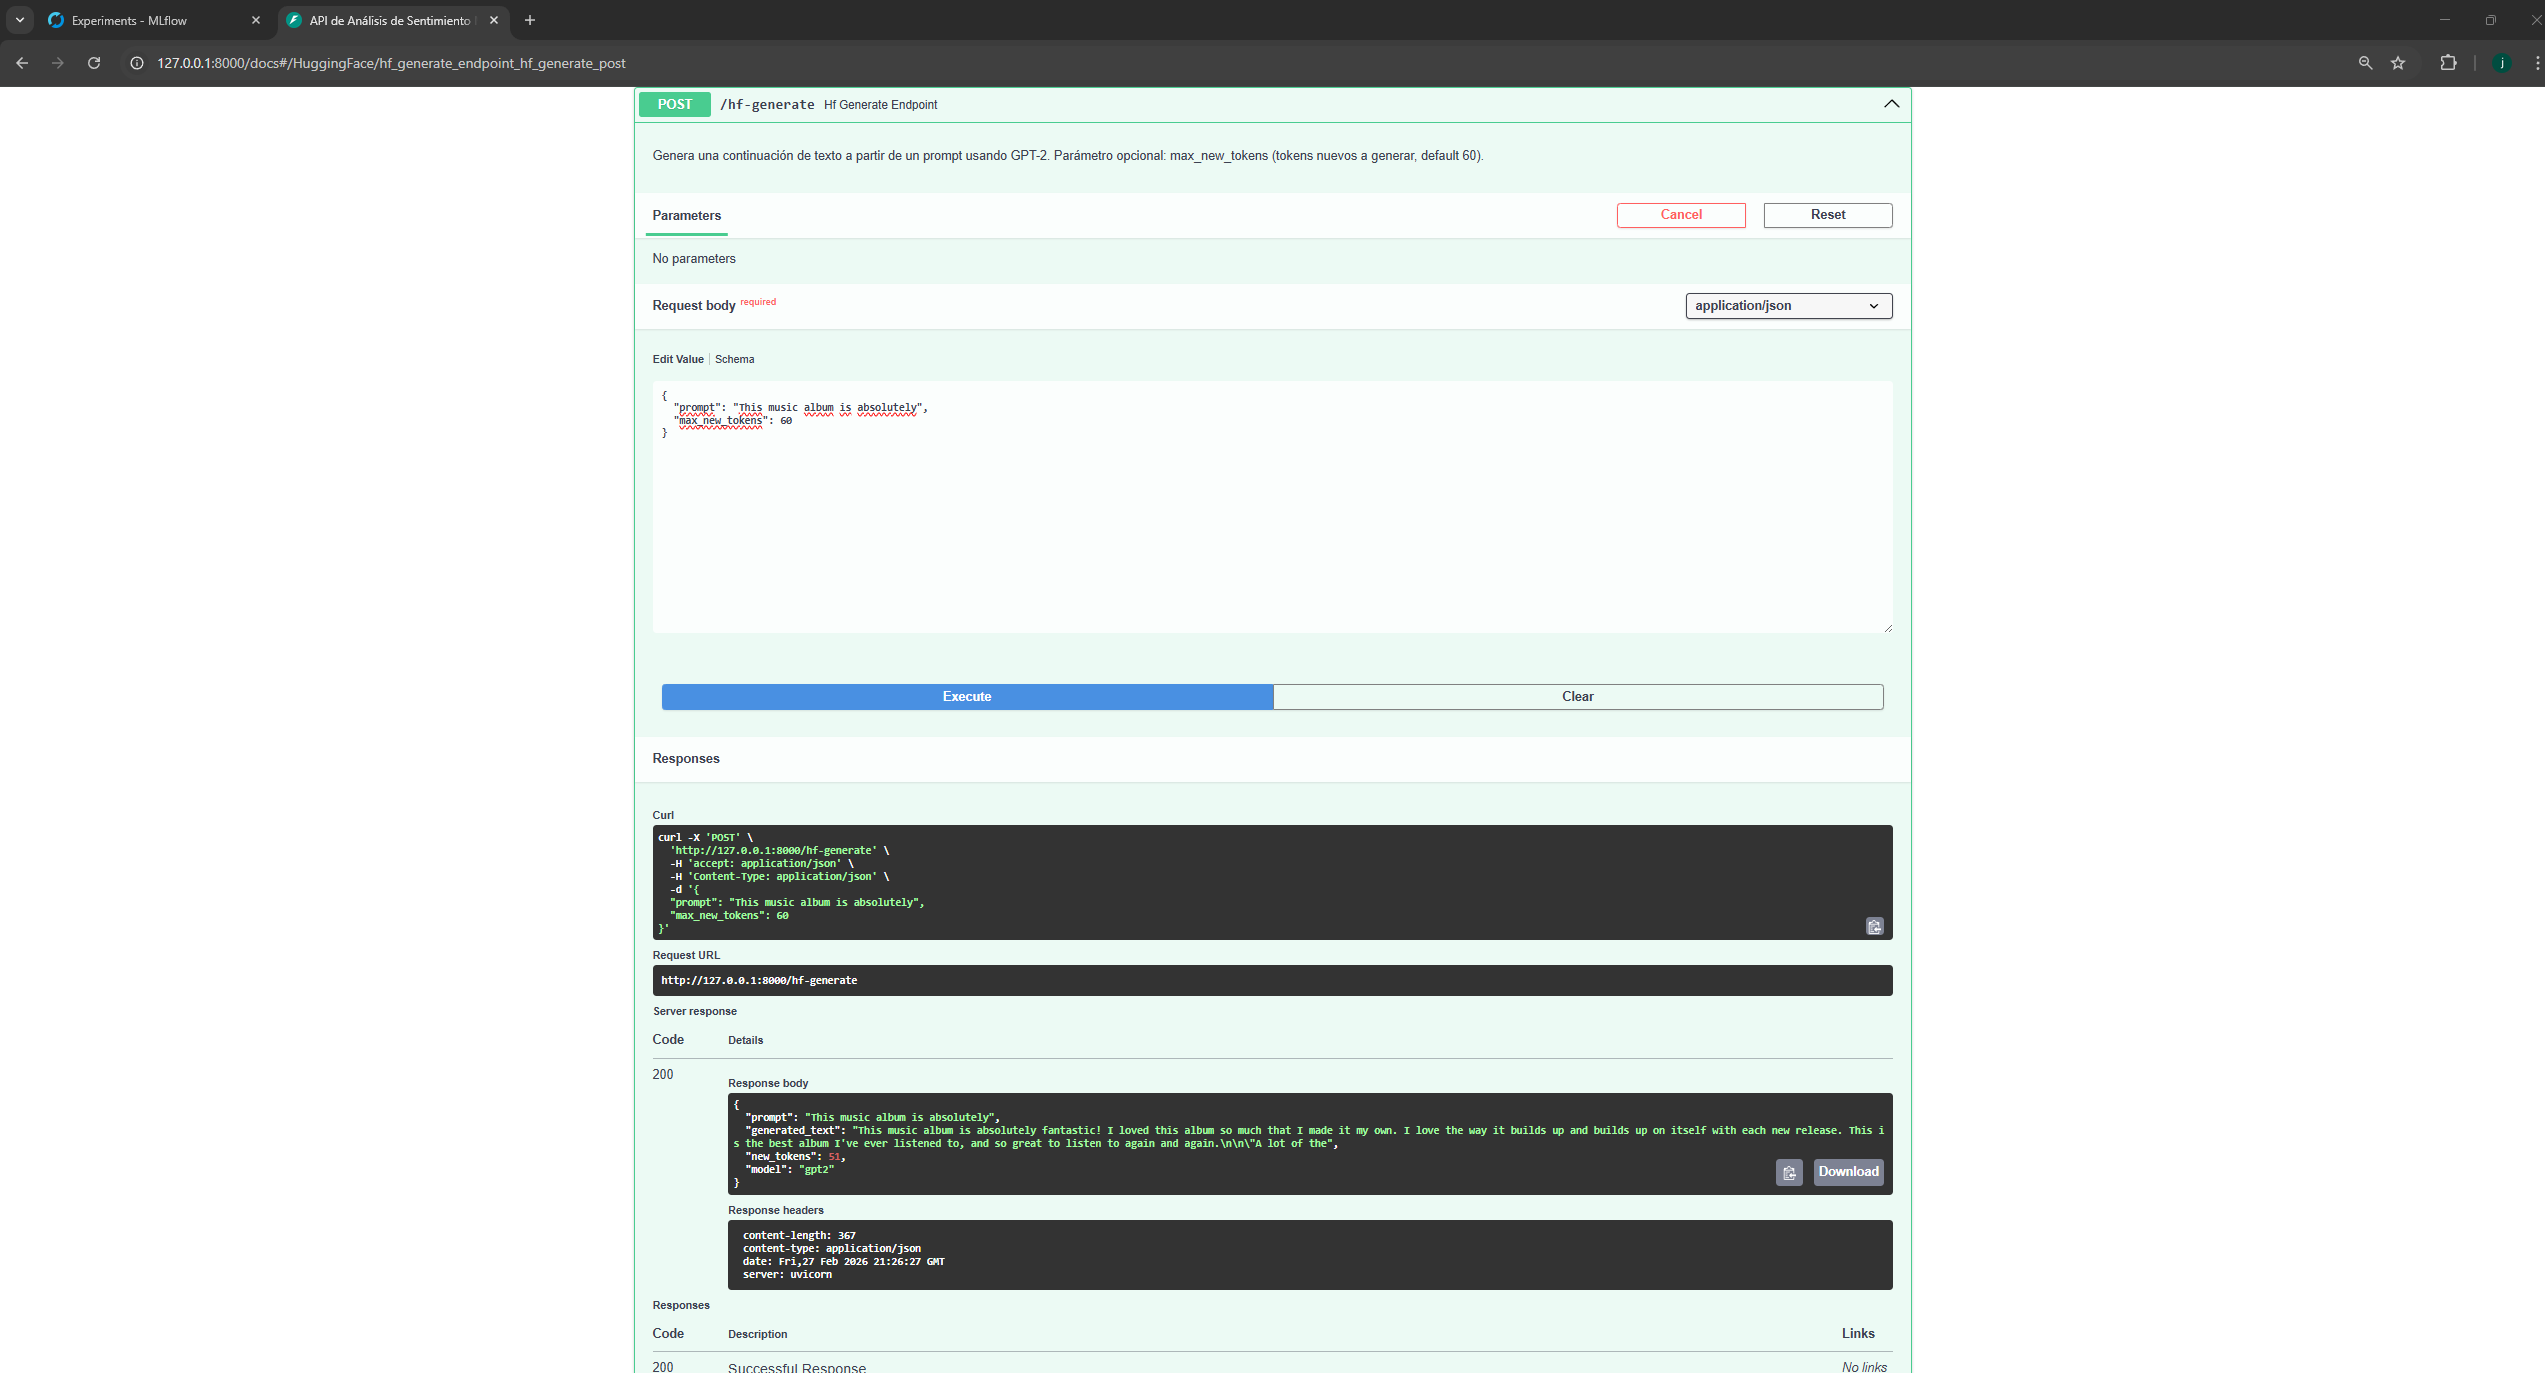

In [23]:
display(Image('Huggin_2.png'))

## Generar .py de funciones y main con al menos dos argumentos de entrada.

In [4]:
%%writefile functions.py
import re
import string
import joblib


def clean_text(text: str, lowercase: bool = True) -> str:
    """
    Limpia el texto eliminando puntuación y espacios extra.

    Args:
        text (str): Texto de entrada.
        lowercase (bool): Si True, convierte a minúsculas.

    Returns:
        str: Texto limpio.
    """
    if lowercase:
        text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def predict_sentiment(model, text: str, clean: bool = True) -> dict:
    """
    Realiza la predicción de sentimiento usando el pipeline de sklearn.

    Args:
        model: Pipeline de sklearn cargado (vectorizador + clasificador).
        text (str): Texto de la reseña a clasificar.
        clean (bool): Si True, limpia el texto antes de predecir.

    Returns:
        dict: Diccionario con 'sentiment', 'prediction_code' y 'confidence'.
    """
    if clean:
        text = clean_text(text)
    pred = model.predict([text])[0]
    proba = model.predict_proba([text])[0]
    return {
        "sentiment": "Positivo" if pred == 1 else "Negativo",
        "prediction_code": int(pred),
        "confidence": round(float(max(proba)), 4)
    }


def get_model_info(model) -> dict:
    """
    Extrae metadatos del pipeline sklearn (vectorizador + clasificador).

    Args:
        model: Pipeline de sklearn con pasos 'vectorizer' y 'classifier'.

    Returns:
        dict: Información del modelo: tipo, hiperparámetros y vocabulario.
    """
    classifier = model.named_steps['classifier']
    vectorizer = model.named_steps['vectorizer']
    vocab_size = len(vectorizer.vocabulary_) if hasattr(vectorizer, 'vocabulary_') else None
    return {
        "model_type": type(classifier).__name__,
        "n_estimators": classifier.n_estimators,
        "max_features_tfidf": vectorizer.max_features,
        "vocabulary_size": vocab_size,
        "stop_words": "english"
    }


def load_model(model_path: str):
    """
    Carga un modelo guardado con joblib.

    Args:
        model_path (str): Ruta al archivo .joblib del modelo.

    Returns:
        Pipeline sklearn cargado.
    """
    return joblib.load(model_path)


Overwriting functions.py


In [5]:
%%writefile train.py
"""
Script de entrenamiento con argumentos de línea de comandos.

Uso:
    python train.py --data-path reviews_Digital_Music_5.json.gz --n-estimators 100
    python train.py --data-path reviews_Digital_Music_5.json.gz --n-estimators 200 --max-features 8000
"""

import argparse
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import mlflow
import mlflow.sklearn


def parse_args():
    parser = argparse.ArgumentParser(
        description="Entrena un modelo de análisis de sentimiento con Random Forest y TF-IDF."
    )
    parser.add_argument("--data-path", type=str, required=True,
                        help="Ruta al archivo JSON con las reseñas")
    parser.add_argument("--n-estimators", type=int, default=100,
                        help="Número de árboles en el Random Forest (default: 100)")
    parser.add_argument("--max-features", type=int, default=5000,
                        help="Número máximo de features para TF-IDF (default: 5000)")
    parser.add_argument("--sample-size", type=int, default=10000,
                        help="Número de muestras a usar (default: 10000)")
    parser.add_argument("--output-model", type=str, default="model_rf.joblib",
                        help="Ruta de salida para guardar el modelo")
    parser.add_argument("--tracking-uri", type=str, default="http://127.0.0.1:5000",
                        help="URI del servidor de MLflow")
    return parser.parse_args()


def main():
    args = parse_args()

    print(f"Cargando datos desde: {args.data_path}")
    df = pd.read_json(args.data_path, lines=True)
    df = df.sample(args.sample_size, random_state=42)
    df['sentiment'] = (df['overall'] > 3).astype(int)
    X = df['reviewText']
    y = df['sentiment']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Datos: {len(X_train)} train | {len(X_test)} test")

    pipeline = Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=args.max_features, stop_words='english')),
        ('classifier', RandomForestClassifier(n_estimators=args.n_estimators, random_state=42, n_jobs=-1))
    ])

    mlflow.set_tracking_uri(args.tracking_uri)
    mlflow.set_experiment("Music_Reviews_Sentiment")

    run_name = f"RF_n{args.n_estimators}_feat{args.max_features}"
    with mlflow.start_run(run_name=run_name):
        pipeline.fit(X_train, y_train)

        acc_train = accuracy_score(y_train, pipeline.predict(X_train))
        acc_test = accuracy_score(y_test, pipeline.predict(X_test))

        print(f"Accuracy Train: {acc_train:.4f}")
        print(f"Accuracy Test:  {acc_test:.4f}")
        print(classification_report(y_test, pipeline.predict(X_test)))

        mlflow.log_param("n_estimators", args.n_estimators)
        mlflow.log_param("max_features_tfidf", args.max_features)
        mlflow.log_param("sample_size", args.sample_size)
        mlflow.log_metric("accuracy_train", acc_train)
        mlflow.log_metric("accuracy_test", acc_test)
        mlflow.sklearn.log_model(pipeline, "model")

    joblib.dump(pipeline, args.output_model)
    print(f"Modelo guardado en: {args.output_model}")


if __name__ == "__main__":
    main()


Overwriting train.py


In [6]:
# Ver los argumentos disponibles del script
!python train.py --help

usage: train.py [-h] --data-path DATA_PATH [--n-estimators N_ESTIMATORS]
                [--max-features MAX_FEATURES] [--sample-size SAMPLE_SIZE]
                [--output-model OUTPUT_MODEL] [--tracking-uri TRACKING_URI]

Entrena un modelo de análisis de sentimiento con Random Forest y TF-IDF.

options:
  -h, --help            show this help message and exit
  --data-path DATA_PATH
                        Ruta al archivo JSON con las reseñas
  --n-estimators N_ESTIMATORS
                        Número de árboles en el Random Forest (default: 100)
  --max-features MAX_FEATURES
                        Número máximo de features para TF-IDF (default: 5000)
  --sample-size SAMPLE_SIZE
                        Número de muestras a usar (default: 10000)
  --output-model OUTPUT_MODEL
                        Ruta de salida para guardar el modelo
  --tracking-uri TRACKING_URI
                        URI del servidor de MLflow


## Práctica parte FastAPI

### Para esta parte de la práctica teneis que generar un script con al menos 5 modulos app.get y dos de ellos tienen que ser pipelines de HF. 

### Parte de la practica se tendra que entregar en capturas de pantalla. Las capturas de pantalla a adjuntas son las siguientes. 

### 1. Captura de la pantalla docs con al menos 5 modulos. 
### 2. Captura de cada una de los modulos con la respuesta dentro de docs. 
### 3. Captura de cada uno de los modulos en la llamada https.
### 4. Todo el codigo usado durante el proceso. Notebooks y scripts.

### Opcional

### 5. Despliegue del script en GCP Cloud Run